# Modelo Supervisado 2: Clasificación de Riesgo Agrícola con **XGBoost**

Este notebook aborda el **Objetivo 3** del proyecto: a partir de variables conocidas *antes* de la
cosecha (estado, municipio, cultivo, modalidad de riego, ciclo agrícola y superficie sembrada),
**clasificar el nivel de riesgo de siniestro** de una siembra en cinco categorías ordinales:

| Código | Nivel de riesgo | Significado |
|:---:|:---|:---|
| 0 | **Sin siniestro** | No se perdió superficie sembrada |
| 1 | **Riesgo bajo** | Se perdió una fracción pequeña del área |
| 2 | **Riesgo medio** | Pérdida intermedia |
| 3 | **Riesgo alto** | Pérdida elevada |
| 4 | **Pérdida crítica** | Pérdida casi total de la siembra |

### ¿Por qué XGBoost?
**XGBoost** (*Extreme Gradient Boosting*) construye árboles de decisión de forma secuencial, donde cada
árbol corrige los errores del anterior mediante *gradient boosting*. Lo elegimos porque:

- Es el estándar de facto para **datos tabulares** heterogéneos y relaciones **no lineales**.
- Incluye **regularización integrada** (`gamma`, `lambda`, `alpha`) que controla el sobreajuste —el eje central de este análisis.
- Maneja el **desbalance de clases** mediante `sample_weight`, sin alterar los datos originales.

> **Reto principal del problema:** el dataset está **severamente desbalanceado** — el ~95 % de los registros
> son "Sin siniestro". Por eso la *accuracy* por sí sola es engañosa y usamos un abanico amplio de métricas
> robustas al desbalance (F1-macro, *balanced accuracy*, Kappa, MCC, AUC-PR).

## Fase 0 · Configuración e importación de librerías

### Cómo leer este notebook

El documento sigue el **flujo natural de un proyecto de modelado**, de principio a fin. En cada fase verás dos tipos de recuadro que te guían:

> **¿Qué buscamos?** — la pregunta o hipótesis que motiva la fase, *antes* de ver resultados.

> **¿Qué obtuvimos?** — la lectura de los números/gráficas reales, *después* del código.

**El recorrido es:**

1. **Fase 1 — Datos:** qué predecimos, con qué variables y por qué partimos el tiempo en pasado/futuro.
2. **Fase 2 — Baseline:** un primer modelo "tal cual" para tener una vara de medir.
3. **Fase 3 — Regularización:** el corazón del análisis; controlar el sobreajuste con `gamma`, `lambda`, `alpha`.
4. **Fase 4 — Modelo final:** el mejor modelo evaluado con una batería completa de métricas.
5. **Fase 5 — Interpretabilidad:** abrir la caja negra (importancia y SHAP) y analizar errores.
6. **Fase 6 — Robustez:** confirmar con validación cruzada que el resultado no fue suerte.

La idea es que, aunque no seas experto/a, al terminar entiendas **qué se hizo, por qué, y qué se logró**.

In [1]:
import sys
sys.path.insert(0, '..')
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import xgboost as xgb

from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, balanced_accuracy_score, log_loss,
    precision_score, recall_score,
    cohen_kappa_score, matthews_corrcoef, fbeta_score,
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve, auc,
)
from sklearn.metrics import make_scorer
from sklearn.model_selection import (
    RandomizedSearchCV, StratifiedKFold, cross_validate, learning_curve,
)
from sklearn.preprocessing import label_binarize

from src.data_loader import DataLoader
from src.xgboost_model import XGBoostDataPrep

# Semilla global para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# sklearn >= 1.6 eliminó `fit_params`. Activamos el ENRUTAMIENTO DE METADATOS
# para poder pasar `sample_weight` a cross_validate / learning_curve vía `params=`.
sklearn.set_config(enable_metadata_routing=True)

# Estilo de gráficas consistente con el resto del proyecto
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
from pathlib import Path
Path('figuras/xgboost').mkdir(parents=True, exist_ok=True)

# Paleta semántica para los 5 niveles de riesgo (verde=seguro ... morado=crítico)
PALETA_RIESGO = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#8e44ad']
print('Versiones -> xgboost:', xgb.__version__, '| scikit-learn:', sklearn.__version__)

# === Metrica de optimizacion alineada al negocio =============================
# El objetivo del problema es NO dejar pasar una "Perdida critica" (clase 4),
# pero sin disparar falsas alarmas. Optimizar solo el recall de la clase 4 es
# hackeable (el modelo predice "critico" de mas). Por eso usamos F2 de la clase
# critica (prioriza recall ~4x sobre precision PERO penaliza falsas alarmas),
# combinada con metricas globales robustas al desbalance.
#
#   Score = 0.50*F2_critica + 0.25*BalancedAcc + 0.15*KappaCuad + 0.10*F1Macro
#
# - F2_critica  : recobrar perdidas casi totales sin inflar falsos positivos.
# - BalancedAcc : recall promedio de las 5 clases (no solo la critica).
# - KappaCuad   : penaliza errores "lejanos" en el orden de riesgo (ordinal).
# - F1Macro     : balance global precision/recall entre clases.
PESOS_SCORE = {'f2_critica': 0.50, 'bal_acc': 0.25, 'kappa_cuad': 0.15, 'f1_macro': 0.10}

def score_compuesto(y_true, y_pred):
    """Metrica compuesta a maximizar (rango ~[-1, 1], en la practica ~[0, 1])."""
    f2_crit = fbeta_score(y_true, y_pred, beta=2, labels=[4],
                          average='macro', zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred)
    kappa_q = cohen_kappa_score(y_true, y_pred, weights='quadratic')
    f1_mac  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    return (PESOS_SCORE['f2_critica'] * f2_crit +
            PESOS_SCORE['bal_acc']   * bal_acc +
            PESOS_SCORE['kappa_cuad']* kappa_q +
            PESOS_SCORE['f1_macro']  * f1_mac)

# scorer para RandomizedSearchCV / cross_validate (mayor = mejor)
scorer_compuesto = make_scorer(score_compuesto, greater_is_better=True)


Versiones -> xgboost: 3.2.0 | scikit-learn: 1.8.0


### Fuente de los datos y su procesamiento

Este modelo **no** procesa los datos: consume el dataset **procesado** que genera el **notebook de EDA** (`notebooks/eda.ipynb`), respetando el flujo del proyecto:

`data/raw/siap_2010_2024.csv`  →  **notebook de EDA**  →  `data/processed/siap_procesado.csv`  →  **modelo**

Todo el **procesamiento** ocurre en el EDA: deriva `proporcion_siniestro` y `nivel_riesgo`, imputa los nulos estructurales, elimina duplicados y exporta el CSV procesado (en utf-8-sig). Aquí el modelo únicamente **lee** ese resultado; si el archivo no existe, primero debe ejecutarse el notebook de EDA.

In [2]:
# === Fuente de datos: dataset PROCESADO por el notebook de EDA ===
# Flujo del proyecto:
#   data/raw/siap_2010_2024.csv  --(notebook de EDA: eda.ipynb)-->  data/processed/siap_procesado.csv
# El procesamiento (derivar proporcion_siniestro y nivel_riesgo, imputar nulos y
# quitar duplicados) ocurre en el EDA, que exporta el CSV procesado. Aqui el
# modelo SOLO consume ese resultado.
RUTA_PROCESADO = Path('..') / 'data' / 'processed' / 'siap_procesado.csv'
if not RUTA_PROCESADO.exists():
    raise FileNotFoundError(
        f'No se encontro {RUTA_PROCESADO}. Ejecuta primero el notebook de EDA '
        '(notebooks/eda.ipynb), que procesa data/raw/siap_2010_2024.csv y exporta el procesado.'
    )

# El procesado se escribe en utf-8-sig (EDAAnalyzer.exportar_dataset_limpio);
# leerlo con el encoding correcto evita el mojibake de 'Perdida critica'.
loader = DataLoader(RUTA_PROCESADO, encoding='utf-8-sig')
df_raw = loader.cargar()

print('Dimensiones del dataset:', df_raw.shape)
# Eliminar los pocos nulos residuales en las columnas base
df_raw = df_raw.dropna(subset=['Sembrada', 'Volumenproduccion']).copy()
print('Tras eliminar nulos residuales:', df_raw.shape)
df_raw[['Anio', 'Idestado', 'Idcultivo', 'Sembrada', 'nivel_riesgo']].head()

[DataLoader] Cargando siap_procesado.csv ...


[DataLoader] 541829 filas , 26 columnas cargadas.
Dimensiones del dataset: (541829, 26)
Tras eliminar nulos residuales: (541826, 26)


,Anio,Idestado,Idcultivo,Sembrada,nivel_riesgo
0,2010,1,5490000,847.0,Sin siniestro
1,2010,1,9090000,370.0,Sin siniestro
2,2010,1,15050000,289.0,Sin siniestro
3,2010,1,5740000,4.0,Sin siniestro
4,2010,1,5940000,15.0,Sin siniestro


## Fase 1 · Ingeniería de *features* y preparación de los datos

La preparación está encapsulada en `src/xgboost_model.py` (clase `XGBoostDataPrep`). Resumen de lo que hace:

1. **Ingeniería de variables:**
   - `log_sembrada = log1p(Sembrada)` → comprime la fuerte asimetría de la superficie sembrada (muchas parcelas chicas, pocas enormes).
   - `interaccion_mod_ciclo = Idmodalidad × Idciclo` → captura el efecto combinado de regar/no regar según el ciclo.
2. **Codificación:** *Label Encoding* para `Idestado`, `Idmunicipio`, `Idcultivo` (alta cardinalidad). `Idciclo` e `Idmodalidad` ya son numéricas.
3. **Variable objetivo:** `nivel_riesgo` → entero ordinal 0–4.

> **Prevención de fuga de información (*data leakage*):** se **excluyen** `Cosechada`, `Siniestrada`,
> `Volumenproduccion`, `Rendimiento`, `Precio`, `Valorproduccion` y `proporcion_siniestro`, porque son
> resultados que solo se conocen *después* de la cosecha. El modelo solo usa información disponible
> **antes** de sembrar/durante el ciclo.

### *Split* temporal (no aleatorio)
Para simular el uso real —entrenar con el pasado para predecir el futuro— partimos por año:

| Conjunto | Años | Uso |
|:--|:--|:--|
| **Entrenamiento** | 2010–2020 | Ajustar el modelo |
| **Validación** | 2021–2022 | Elegir hiperparámetros |
| **Test** | 2023–2024 | Evaluación final e imparcial (datos nunca vistos) |

> **Sobre la estandarización:** XGBoost se basa en árboles de decisión y es **invariante a la escala** de las variables, por lo que **no se requiere** normalizar ni estandarizar las numéricas. La única transformación aplicada es `log1p` sobre la superficie sembrada, para reducir su asimetría.

In [3]:
prep = XGBoostDataPrep(df_raw)
df_processed = prep.preprocess()

(X_train, y_train), (X_val, y_val), (X_test, y_test) = prep.temporal_split()

# Renombrar columnas a nombres legibles para que TODAS las gráficas se entiendan
nombres = prep.FEATURES_LEGIBLES
X_train = X_train.rename(columns=nombres)
X_val   = X_val.rename(columns=nombres)
X_test  = X_test.rename(columns=nombres)

target_names = list(prep.riesgo_map.keys())   # ['Sin siniestro', ..., 'Pérdida crítica']

# Pesos por clase para compensar el desbalance (solo en entrenamiento)
sample_weights = prep.get_sample_weights(y_train)

Iniciando preprocesamiento de datos para XGBoost...


Preprocesamiento completado.
  Filas: 541,826
  Distribución target: {0: np.int64(515009), 1: np.int64(7072), 2: np.int64(8475), 3: np.int64(5197), 4: np.int64(6073)}

Features utilizadas (8): ['Anio', 'Idestado_encoded', 'Idmunicipio_encoded', 'Idciclo', 'Idmodalidad', 'Idcultivo_encoded', 'log_sembrada', 'interaccion_mod_ciclo']
Entrenamiento (2010-2020): 395,273 registros (73.0%)
Validación    (2021-2022): 66,293 registros (12.2%)
Test          (2023-2024): 80,260 registros (14.8%)

Pesos de clase calculados (balanced):
  Clase 0: 0.2120
  Clase 1: 13.0003
  Clase 2: 11.5560
  Clase 3: 18.5792
  Clase 4: 15.2851


### El desbalance de clases, visto de frente
Antes de modelar, visualizamos *por qué* este problema es difícil. La siguiente gráfica muestra cuántos
registros hay de cada nivel de riesgo: la clase "Sin siniestro" domina de forma abrumadora. Un modelo
ingenuo que prediga siempre "Sin siniestro" acertaría ~95 % de las veces **sin aprender nada útil** — de
ahí que necesitemos pesos por clase y métricas que premien detectar las clases minoritarias.

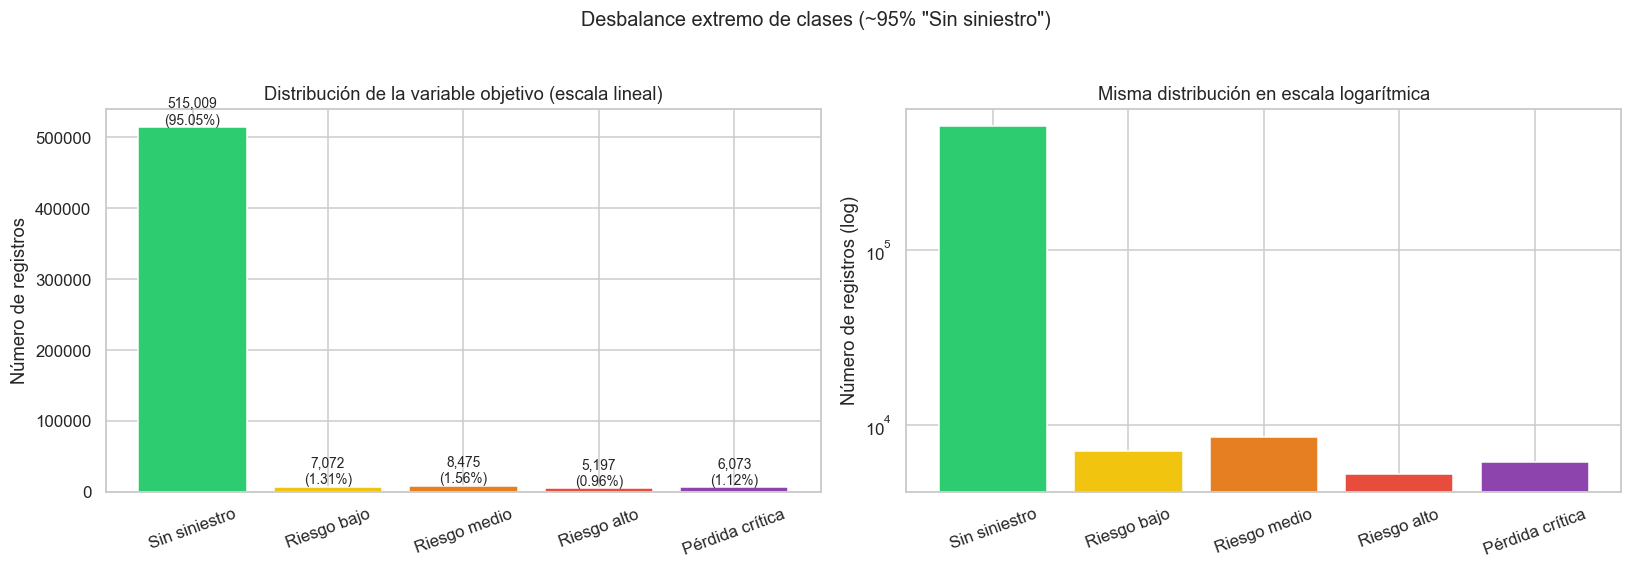

In [4]:
dist = pd.Series(prep.df['target']).value_counts().sort_index()
dist.index = target_names

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
bars = axes[0].bar(dist.index, dist.values, color=PALETA_RIESGO, edgecolor='white')
axes[0].set_title('Distribución de la variable objetivo (escala lineal)', fontsize=12)
axes[0].set_ylabel('Número de registros')
for b, v in zip(bars, dist.values):
    axes[0].text(b.get_x()+b.get_width()/2, v, f'{v:,}\n({v/dist.sum()*100:.2f}%)',
                 ha='center', va='bottom', fontsize=9)
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(dist.index, dist.values, color=PALETA_RIESGO, edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('Misma distribución en escala logarítmica', fontsize=12)
axes[1].set_ylabel('Número de registros (log)')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Desbalance extremo de clases (~95% "Sin siniestro")', fontsize=13, y=1.03)
plt.tight_layout()
plt.savefig('figuras/xgboost/01_distribucion_clases_target.png', dpi=150, bbox_inches='tight')
plt.show()

> **¿Qué obtuvimos?** La gráfica confirma el reto de raíz: de los **541 826** registros, **515 009 (≈95.0 %)** son *"Sin siniestro"*. Las cuatro clases de riesgo juntas apenas suman ~5 %, y la más rara —*Riesgo alto*— es apenas el **0.96 %**. Esto tiene dos consecuencias que marcan todo lo que sigue:

> 1. **La *accuracy* es engañosa:** un modelo que dijera siempre "Sin siniestro" acertaría el 95 % sin aprender nada. Por eso priorizamos **F1-macro** y **balanced accuracy**.
> 2. **Necesitamos `sample_weight`:** los pesos calculados van de **0.21** (clase mayoritaria) hasta **18.6** (clase rara). Así, equivocarse en una siembra de riesgo "pesa" ~88× más que en una sin siniestro, obligando al modelo a prestarles atención.

## Fase 2 · Modelo *baseline* (XGBoost sin optimizar)

Entrenamos un primer XGBoost con hiperparámetros por defecto. Su único propósito es servir de **línea
base de referencia**: cualquier mejora posterior (regularización, *tuning*) se medirá contra él.

- `objective='multi:softprob'`: clasificación multiclase devolviendo **probabilidades** por clase.
- `eval_metric=['mlogloss','merror']`: registramos el error en train y validación en cada iteración
  para poder dibujar la **curva de entrenamiento**.
- `sample_weight`: aplica los pesos por clase para que el modelo no ignore a las minoritarias.

In [5]:
xgb_baseline = xgb.XGBClassifier(
    objective='multi:softprob',
    eval_metric=['mlogloss', 'merror'],
    n_estimators=300,
    tree_method='hist',
    random_state=RANDOM_STATE,
)

print('Entrenando modelo baseline...')
xgb_baseline.fit(
    X_train, y_train,
    sample_weight=sample_weights,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)
print('Modelo baseline entrenado.')

Entrenando modelo baseline...


Modelo baseline entrenado.


### Curva de entrenamiento (¿cuántos árboles necesitamos?)
La curva de entrenamiento muestra cómo evoluciona el error a medida que se agregan árboles (`n_estimators`).
Comparando **train** vs **validación** detectamos sobreajuste: si el error de train sigue bajando pero el
de validación se estanca o sube, el modelo está memorizando ruido. Es la motivación directa de la Fase 3.

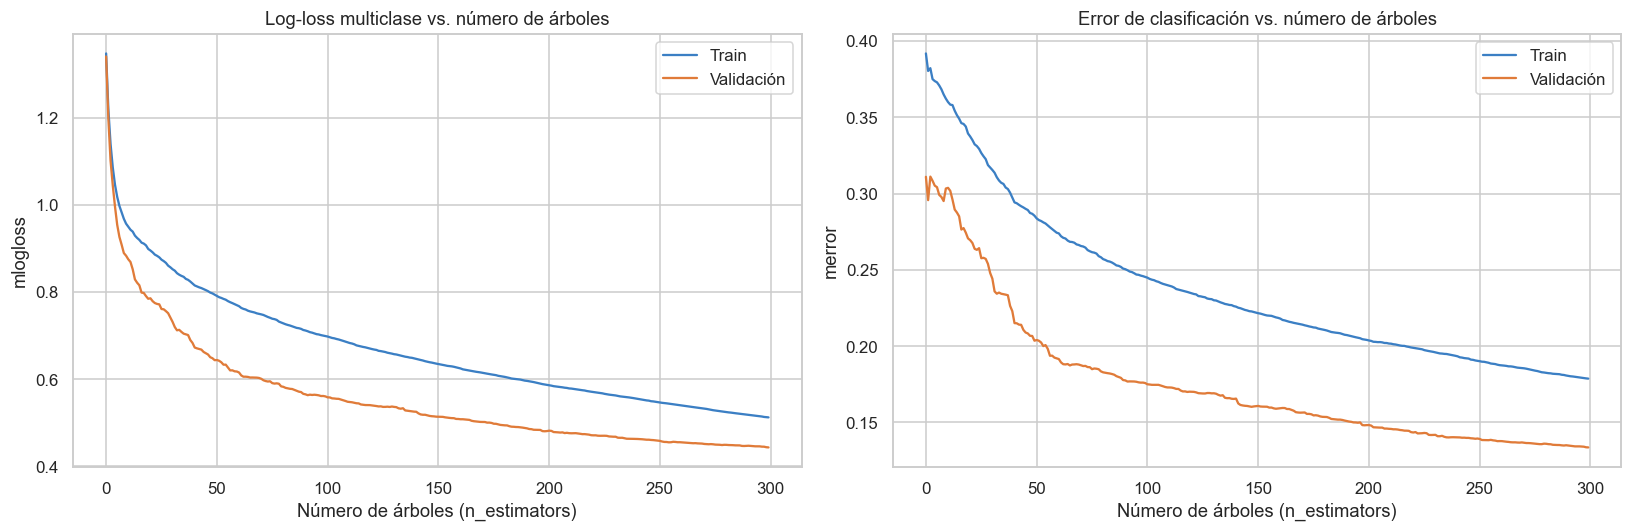

In [6]:
results = xgb_baseline.evals_result()
epochs = range(len(results['validation_0']['mlogloss']))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(epochs, results['validation_0']['mlogloss'], label='Train', color='#3b7fc4')
axes[0].plot(epochs, results['validation_1']['mlogloss'], label='Validación', color='#e07b39')
axes[0].set_title('Log-loss multiclase vs. número de árboles', fontsize=12)
axes[0].set_xlabel('Número de árboles (n_estimators)'); axes[0].set_ylabel('mlogloss'); axes[0].legend()

axes[1].plot(epochs, results['validation_0']['merror'], label='Train', color='#3b7fc4')
axes[1].plot(epochs, results['validation_1']['merror'], label='Validación', color='#e07b39')
axes[1].set_title('Error de clasificación vs. número de árboles', fontsize=12)
axes[1].set_xlabel('Número de árboles (n_estimators)'); axes[1].set_ylabel('merror'); axes[1].legend()

plt.tight_layout()
plt.savefig('figuras/xgboost/02_curva_entrenamiento_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

### Evaluación del *baseline* en validación
El **reporte de clasificación** desglosa, por clase, tres métricas fundamentales:

- **Precision** = de todo lo que el modelo predijo como clase *X*, ¿qué fracción era realmente *X*? (penaliza falsos positivos).
- **Recall** (sensibilidad) = de todos los casos que **eran** clase *X*, ¿cuántos detectó? (penaliza falsos negativos).
- **F1-score** = media armónica de *precision* y *recall*; resume ambas en un solo número.

El **F1-macro** (promedio simple entre clases) es nuestra métrica guía porque trata a todas las clases por
igual, sin dejar que la clase mayoritaria domine.

In [7]:
y_val_pred = xgb_baseline.predict(X_val)

print('=== Reporte de Clasificación · Baseline (Validación 2021-2022) ===')
print(classification_report(y_val, y_val_pred, labels=list(range(5)),
                            target_names=target_names, zero_division=0))

f1_macro_base = f1_score(y_val, y_val_pred, average='macro')
acc_base = accuracy_score(y_val, y_val_pred)
print(f'F1-Score (Macro): {f1_macro_base:.4f}')
print(f'Accuracy:         {acc_base:.4f}')

=== Reporte de Clasificación · Baseline (Validación 2021-2022) ===
                 precision    recall  f1-score   support

  Sin siniestro       0.99      0.88      0.93     64843
    Riesgo bajo       0.06      0.32      0.10       465
   Riesgo medio       0.03      0.17      0.06       538
    Riesgo alto       0.04      0.28      0.07       288
Pérdida crítica       0.01      0.09      0.02       159

       accuracy                           0.87     66293
      macro avg       0.23      0.35      0.24     66293
   weighted avg       0.97      0.87      0.91     66293

F1-Score (Macro): 0.2356
Accuracy:         0.8664


> **¿Qué obtuvimos?** El baseline alcanza **accuracy 0.866** pero un **F1-macro de solo 0.236**. Esa brecha es exactamente el síntoma del desbalance: acierta casi siempre en "Sin siniestro" (*recall* 0.88) pero **fracasa en las clases de riesgo**. Por ejemplo, en *Pérdida crítica* logra *recall* 0.09 y *precision* 0.01: detecta pocas y, de las que marca, casi todas son falsas alarmas. En otras palabras, **el modelo "crudo" sí intenta marcar riesgos, pero lo hace muy mal**. Este 0.236 es la vara que tendremos que superar.

### Matriz de confusión del *baseline*
La **matriz de confusión** cruza el valor real (filas) contra la predicción (columnas). La diagonal son los
aciertos; fuera de la diagonal están los errores. Nos permite ver *qué* clases se confunden entre sí
(p. ej. si "Riesgo medio" se confunde con "Riesgo alto", que son adyacentes).

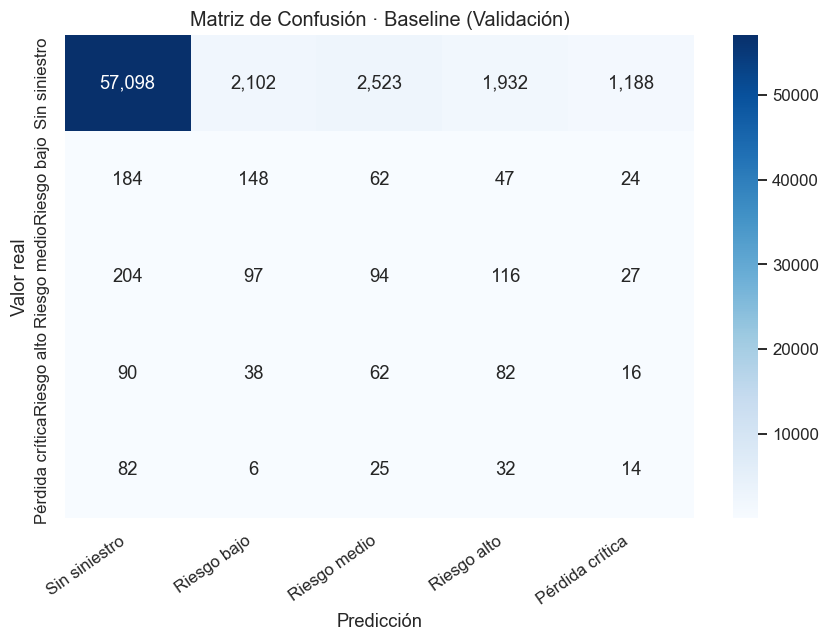

In [8]:
cm_base = confusion_matrix(y_val, y_val_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_base, annot=True, fmt=',d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=ax)
ax.set_title('Matriz de Confusión · Baseline (Validación)', fontsize=13)
ax.set_ylabel('Valor real'); ax.set_xlabel('Predicción')
plt.xticks(rotation=35, ha='right'); plt.tight_layout()
plt.savefig('figuras/xgboost/03_confusion_matrix_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

> **¿Qué obtuvimos?** Fuera de la diagonal vemos que los errores **no son aleatorios**: el modelo tiende a confundir niveles **adyacentes** (medio↔alto, bajo↔medio), lo cual es esperable y "menos grave" en un problema ordinal. El problema serio es la dispersión de las clases minoritarias hacia "Sin siniestro". Esto motiva la **Fase 3**: regularizar para que el modelo generalice en vez de reaccionar al ruido.

## Fase 3 · Regularización: `gamma`, `lambda` (L2) y `alpha` (L1)

Esta es la **sección central** del análisis. La regularización combate el sobreajuste penalizando la
complejidad del modelo. XGBoost ofrece tres palancas, que estudiamos primero **una por una** (para aislar
su efecto) y luego **en conjunto**.

La función objetivo de XGBoost es **Pérdida + Regularización**:

$$\mathcal{L} = \sum_i l(\hat{y}_i, y_i) \;+\; \sum_k \Big[ \gamma\, T_k + \tfrac{1}{2}\lambda \lVert w_k \rVert^2 + \alpha \lVert w_k \rVert_1 \Big]$$

donde $T_k$ es el número de hojas del árbol $k$ y $w_k$ sus pesos. La ganancia de un *split* es:

$$\text{Ganancia} = \frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda} - \gamma$$

| Hiperparámetro | Qué penaliza | Efecto | Default |
|:--|:--|:--|:--:|
| **`gamma`** ($\gamma$) | Ganancia mínima para abrir un *split* | Poda ramas poco útiles → árboles más simples | 0 |
| **`lambda`** ($\lambda$, L2) | Magnitud **al cuadrado** de los pesos | Suaviza predicciones, reduce varianza | 1 |
| **`alpha`** ($\alpha$, L1) | Magnitud **absoluta** de los pesos | Lleva pesos a 0 → *sparsity* | 0 |

### Experimento 1 — Efecto individual de `gamma`

In [9]:
def evaluar(model):
    model.fit(X_train, y_train, sample_weight=sample_weights,
              eval_set=[(X_val, y_val)], verbose=False)
    yp = model.predict(X_val); pp = model.predict_proba(X_val)
    return (f1_score(y_val, yp, average='macro'),
            accuracy_score(y_val, yp),
            log_loss(y_val, pp, labels=list(range(5))))

def base_model(**kw):
    p = dict(objective='multi:softprob', n_estimators=200, tree_method='hist',
             random_state=RANDOM_STATE)
    p.update(kw); return xgb.XGBClassifier(**p)

gamma_values = [0, 0.1, 0.5, 1, 2, 5, 10]
gamma_results = []
for g in gamma_values:
    f1, acc, ll = evaluar(base_model(gamma=g, reg_lambda=1, reg_alpha=0))
    gamma_results.append({'gamma': g, 'f1_macro': f1, 'accuracy': acc, 'logloss': ll})
    print(f'  gamma={g:>5} -> F1-macro={f1:.4f}  logloss={ll:.4f}')

df_gamma = pd.DataFrame(gamma_results)
best_gamma = df_gamma.loc[df_gamma['f1_macro'].idxmax(), 'gamma']
print('\nMejor gamma:', best_gamma)
df_gamma

  gamma=    0 -> F1-macro=0.2322  logloss=0.4806


  gamma=  0.1 -> F1-macro=0.2330  logloss=0.4774


  gamma=  0.5 -> F1-macro=0.2290  logloss=0.5125


  gamma=    1 -> F1-macro=0.2269  logloss=0.5457


  gamma=    2 -> F1-macro=0.2236  logloss=0.5815


  gamma=    5 -> F1-macro=0.2168  logloss=0.6580


  gamma=   10 -> F1-macro=0.2121  logloss=0.7209

Mejor gamma: 0.1


,gamma,f1_macro,accuracy,logloss
0,0.0,0.232248,0.851779,0.480635
1,0.1,0.232996,0.855852,0.477438
2,0.5,0.228994,0.838957,0.512470
3,1.0,0.226895,0.827448,0.545727
4,2.0,0.223565,0.819951,0.581539
5,5.0,0.216773,0.792587,0.658018
6,10.0,0.212148,0.769206,0.720944


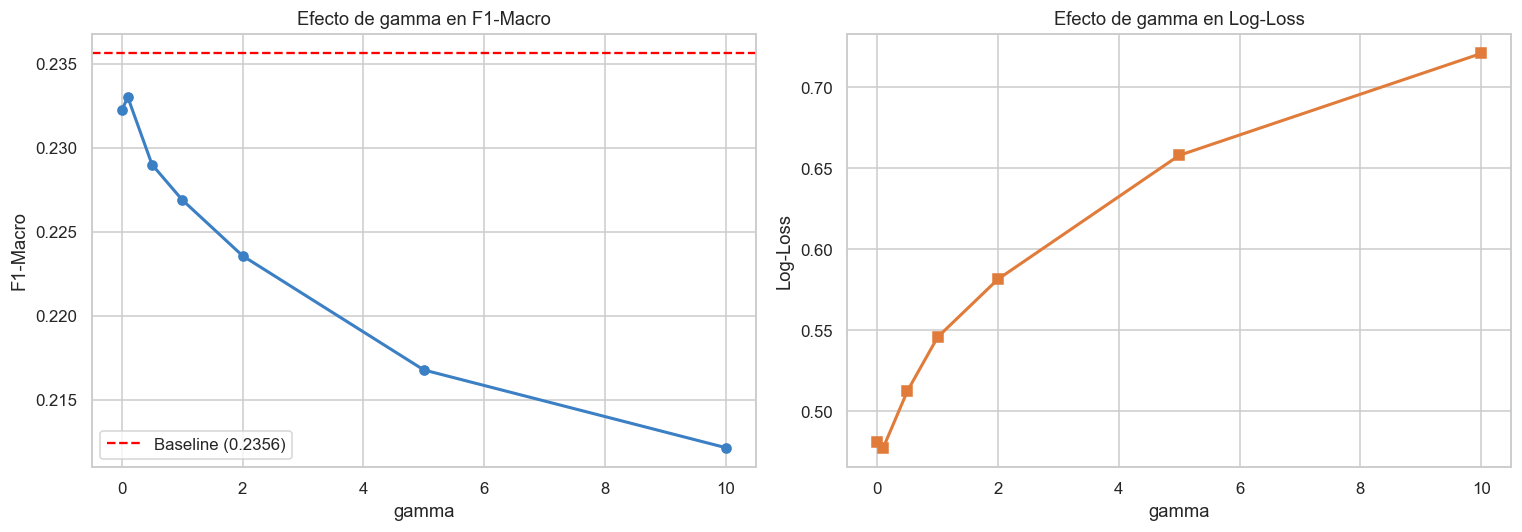

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(df_gamma['gamma'], df_gamma['f1_macro'], marker='o', color='#3b7fc4', lw=2)
axes[0].axhline(f1_macro_base, color='red', ls='--', label=f'Baseline ({f1_macro_base:.4f})')
axes[0].set_title('Efecto de gamma en F1-Macro'); axes[0].set_xlabel('gamma'); axes[0].set_ylabel('F1-Macro'); axes[0].legend()
axes[1].plot(df_gamma['gamma'], df_gamma['logloss'], marker='s', color='#e07b39', lw=2)
axes[1].set_title('Efecto de gamma en Log-Loss'); axes[1].set_xlabel('gamma'); axes[1].set_ylabel('Log-Loss')
plt.tight_layout(); plt.savefig('figuras/xgboost/04_exp1_gamma.png', dpi=150, bbox_inches='tight'); plt.show()

> **¿Qué obtuvimos?** El mejor `gamma` es **0.1** (F1-macro 0.233), apenas por encima del valor por defecto. A partir de ahí, subir `gamma` **degrada todo**: con `gamma=10` el F1 cae a 0.212 y el *log-loss* casi se duplica (0.48 → 0.72). Lectura: en estos datos **podar agresivamente los *splits* hace más daño que bien**; basta una poda suave.

### Experimento 2 — Efecto individual de `lambda` (L2)

**¿Qué buscamos?** Fijamos `gamma` en su mejor valor y barremos `lambda` (penalización **L2**, sobre el *cuadrado* de los pesos de las hojas). Esperamos ver una curva en forma de **U invertida**: poca regularización deja sobreajustar; demasiada aplana el modelo y empeora. El óptimo está en el medio.

In [11]:
lambda_values = [0, 0.01, 0.1, 1, 5, 10, 50, 100]
lambda_results = []
for l in lambda_values:
    f1, acc, ll = evaluar(base_model(gamma=best_gamma, reg_lambda=l, reg_alpha=0))
    lambda_results.append({'reg_lambda': l, 'f1_macro': f1, 'accuracy': acc, 'logloss': ll})
    print(f'  lambda={l:>6} -> F1-macro={f1:.4f}  logloss={ll:.4f}')

df_lambda = pd.DataFrame(lambda_results)
best_lambda = df_lambda.loc[df_lambda['f1_macro'].idxmax(), 'reg_lambda']
print('\nMejor lambda:', best_lambda)
df_lambda

  lambda=     0 -> F1-macro=0.2321  logloss=0.4808


  lambda=  0.01 -> F1-macro=0.2346  logloss=0.4763


  lambda=   0.1 -> F1-macro=0.2326  logloss=0.4785


  lambda=     1 -> F1-macro=0.2330  logloss=0.4774


  lambda=     5 -> F1-macro=0.2313  logloss=0.4947


  lambda=    10 -> F1-macro=0.2274  logloss=0.5180


  lambda=    50 -> F1-macro=0.2296  logloss=0.5479


  lambda=   100 -> F1-macro=0.2259  logloss=0.5706

Mejor lambda: 0.01


,reg_lambda,f1_macro,accuracy,logloss
0,0.00,0.232118,0.854540,0.480751
1,0.01,0.234555,0.858552,0.476281
2,0.10,0.232577,0.855053,0.478546
3,1.00,0.232996,0.855852,0.477438
4,5.00,0.231281,0.846831,0.494656
5,10.00,0.227438,0.837223,0.518043
6,50.00,0.229558,0.828549,0.547859
7,100.00,0.225857,0.818367,0.570614


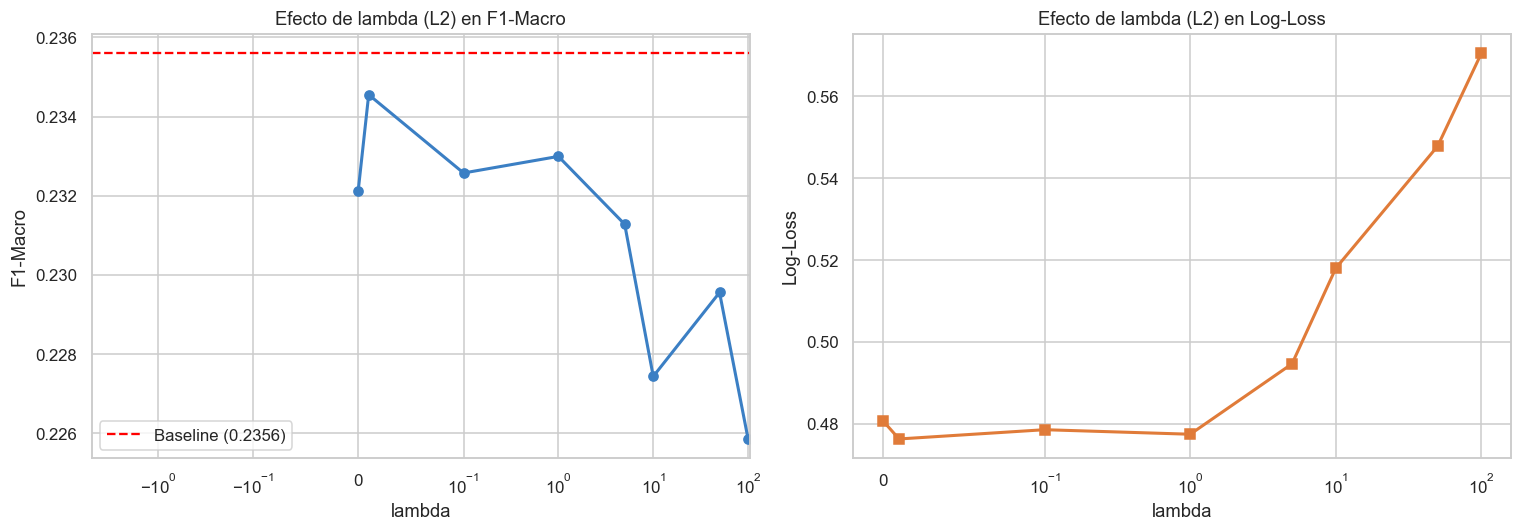

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(df_lambda['reg_lambda'], df_lambda['f1_macro'], marker='o', color='#3b7fc4', lw=2)
axes[0].axhline(f1_macro_base, color='red', ls='--', label=f'Baseline ({f1_macro_base:.4f})')
axes[0].set_xscale('symlog', linthresh=0.1)
axes[0].set_title('Efecto de lambda (L2) en F1-Macro'); axes[0].set_xlabel('lambda'); axes[0].set_ylabel('F1-Macro'); axes[0].legend()
axes[1].plot(df_lambda['reg_lambda'], df_lambda['logloss'], marker='s', color='#e07b39', lw=2)
axes[1].set_xscale('symlog', linthresh=0.1)
axes[1].set_title('Efecto de lambda (L2) en Log-Loss'); axes[1].set_xlabel('lambda'); axes[1].set_ylabel('Log-Loss')
plt.tight_layout(); plt.savefig('figuras/xgboost/05_exp2_lambda.png', dpi=150, bbox_inches='tight'); plt.show()

> **¿Qué obtuvimos?** Aparece la **U invertida** esperada: el óptimo es `lambda=0.01` (F1-macro 0.235, el mejor *log-loss* del barrido), y al pasar de `lambda=10` el desempeño se deteriora de forma sostenida. La mejora respecto al *default* es pequeña, lo que adelanta una idea clave: **ajustar un solo regularizador no mueve mucho la aguja**.

### Experimento 3 — Efecto individual de `alpha` (L1)

**¿Qué buscamos?** Igual que antes, pero con `alpha` (penalización **L1**, sobre el *valor absoluto* de los pesos). A diferencia de L2, L1 puede llevar pesos **exactamente a 0**, eliminando hojas poco útiles. Buscamos el valor que maximice el F1-macro sin disparar el *log-loss*.

In [13]:
alpha_values = [0, 0.001, 0.01, 0.1, 1, 5, 10, 50]
alpha_results = []
for a in alpha_values:
    f1, acc, ll = evaluar(base_model(gamma=best_gamma, reg_lambda=best_lambda, reg_alpha=a))
    alpha_results.append({'reg_alpha': a, 'f1_macro': f1, 'accuracy': acc, 'logloss': ll})
    print(f'  alpha={a:>6} -> F1-macro={f1:.4f}  logloss={ll:.4f}')

df_alpha = pd.DataFrame(alpha_results)
best_alpha = df_alpha.loc[df_alpha['f1_macro'].idxmax(), 'reg_alpha']
print('\nMejor alpha:', best_alpha)
df_alpha

  alpha=     0 -> F1-macro=0.2346  logloss=0.4763


  alpha= 0.001 -> F1-macro=0.2321  logloss=0.4763


  alpha=  0.01 -> F1-macro=0.2351  logloss=0.4743


  alpha=   0.1 -> F1-macro=0.2348  logloss=0.4777


  alpha=     1 -> F1-macro=0.2325  logloss=0.4878


  alpha=     5 -> F1-macro=0.2305  logloss=0.5105


  alpha=    10 -> F1-macro=0.2306  logloss=0.5221


  alpha=    50 -> F1-macro=0.2218  logloss=0.6185

Mejor alpha: 0.01


,reg_alpha,f1_macro,accuracy,logloss
0,0.000,0.234555,0.858552,0.476281
1,0.001,0.232063,0.853801,0.476294
2,0.010,0.235088,0.858024,0.474284
3,0.100,0.234779,0.856259,0.477675
4,1.000,0.232528,0.849894,0.487800
5,5.000,0.230539,0.842608,0.510461
6,10.000,0.230571,0.840496,0.522076
7,50.000,0.221827,0.802770,0.618509


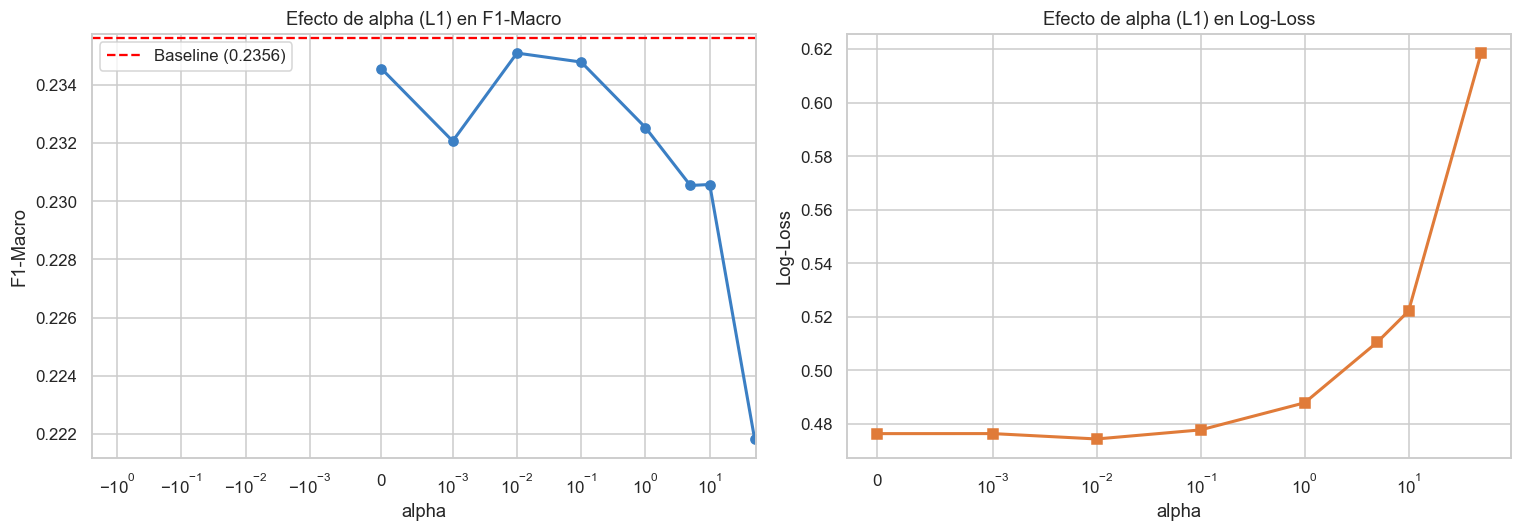

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(df_alpha['reg_alpha'], df_alpha['f1_macro'], marker='o', color='#3b7fc4', lw=2)
axes[0].axhline(f1_macro_base, color='red', ls='--', label=f'Baseline ({f1_macro_base:.4f})')
axes[0].set_xscale('symlog', linthresh=0.001)
axes[0].set_title('Efecto de alpha (L1) en F1-Macro'); axes[0].set_xlabel('alpha'); axes[0].set_ylabel('F1-Macro'); axes[0].legend()
axes[1].plot(df_alpha['reg_alpha'], df_alpha['logloss'], marker='s', color='#e07b39', lw=2)
axes[1].set_xscale('symlog', linthresh=0.001)
axes[1].set_title('Efecto de alpha (L1) en Log-Loss'); axes[1].set_xlabel('alpha'); axes[1].set_ylabel('Log-Loss')
plt.tight_layout(); plt.savefig('figuras/xgboost/06_exp3_alpha.png', dpi=150, bbox_inches='tight'); plt.show()

> **¿Qué obtuvimos?** El mejor `alpha` es **0.01** (F1-macro 0.235) y, como con `lambda`, la ganancia individual es marginal. Confirmamos el patrón de los tres experimentos: **afinar `gamma`, `lambda` o `alpha` por separado deja el F1-macro estancado alrededor de 0.23–0.24.** La pregunta natural es: ¿y si los combinamos?

### Experimento 4 — Búsqueda conjunta con `RandomizedSearchCV`
Los efectos individuales ignoran las **interacciones** entre hiperparámetros. Aquí exploramos
combinaciones al azar de los tres regularizadores junto con otros parámetros clave (`max_depth`,
`learning_rate`, etc.), validando cada candidato con **validación cruzada estratificada** (3 *folds*)
y optimizando el **F1-macro**.

> *Nota técnica:* como sklearn ≥ 1.6 enruta `sample_weight` por metadatos, marcamos el estimador con
> `.set_fit_request(sample_weight=True)` para que la búsqueda lo aplique correctamente en cada *fold*.

> **Criterio de optimización: un *score* compuesto alineado al negocio.**
> A partir de aquí, tanto la búsqueda de hiperparámetros (`RandomizedSearchCV` y Optuna) como el ajuste del umbral **dejan de optimizar el F1-macro** y pasan a maximizar una métrica diseñada para *este* problema:
>
> $$\text{Score} = 0.50\cdot F2_{\text{crítica}} + 0.25\cdot \text{BalAcc} + 0.15\cdot \kappa_{\text{cuad}} + 0.10\cdot F1_{\text{macro}}$$
>
> | Término | Peso | Por qué |
> |:--|:--:|:--|
> | **F2 de *Pérdida crítica*** | 0.50 | Es la clase de mayor costo (seguridad alimentaria). Usamos **F2** (no recall a secas) porque prioriza el *recall* ~4× sobre la *precisión* **pero sigue penalizando las falsas alarmas** — así el modelo no puede "hacer trampa" prediciendo *crítico* de más. |
> | **Balanced Accuracy** | 0.25 | *Recall* promedio de las **5** clases; evita descuidar los niveles intermedios. |
> | **Kappa cuadrático** | 0.15 | Componente **ordinal**: penaliza más confundir *bajo↔crítico* que *alto↔crítico*. |
> | **F1-macro** | 0.10 | Balance global precisión/*recall* entre clases. |
>
> **Por qué estos pesos:** F2_crítica y *Balanced Accuracy* comparten señal de *recall* (la clase crítica está dentro de BalAcc), así que concentramos el peso de *recall* donde de verdad importa (la clase 4) y dejamos a BalAcc cubrir las clases restantes. Kappa cuadrático y F1-macro aportan señal **complementaria** (orden ordinal y balance global), con peso menor. La función `score_compuesto(...)` quedó definida en la celda de *imports*.

In [15]:
param_dist = {
    'gamma':            [0, 0.1, 0.5, 1, 2, 5],
    'reg_lambda':       [0.01, 0.1, 1, 5, 10, 50],
    'reg_alpha':        [0, 0.01, 0.1, 1, 5, 10],
    'max_depth':        [3, 5, 7, 9],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'n_estimators':     [100, 200, 300],
    'min_child_weight': [1, 3, 5, 10],
    'subsample':        [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
}

xgb_search = xgb.XGBClassifier(objective='multi:softprob', tree_method='hist',
                               random_state=RANDOM_STATE)
xgb_search.set_fit_request(sample_weight=True)   # enrutamiento de metadatos (sklearn >=1.6)

random_search = RandomizedSearchCV(
    estimator=xgb_search, param_distributions=param_dist,
    n_iter=40, scoring=scorer_compuesto,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1, random_state=RANDOM_STATE, return_train_score=True, verbose=1,
)

print('Optimizando el SCORE COMPUESTO (F2_critica/BalAcc/KappaCuad/F1Macro)')
print('Buscando hiperparámetros (40 combinaciones x 3 folds)...')
random_search.fit(X_train, y_train, sample_weight=sample_weights.to_numpy())

print(f'\nMejor F1-Macro (CV): {random_search.best_score_:.4f}')
for k, v in random_search.best_params_.items():
    print(f'  {k}: {v}')

Optimizando el SCORE COMPUESTO (F2_critica/BalAcc/KappaCuad/F1Macro)
Buscando hiperparámetros (40 combinaciones x 3 folds)...
Fitting 3 folds for each of 40 candidates, totalling 120 fits



Mejor F1-Macro (CV): 0.4063
  subsample: 0.7
  reg_lambda: 0.01
  reg_alpha: 0.1
  n_estimators: 300
  min_child_weight: 10
  max_depth: 9
  learning_rate: 0.1
  gamma: 0.1
  colsample_bytree: 0.8


In [16]:
cv_results = pd.DataFrame(random_search.cv_results_)
cols = ['rank_test_score', 'mean_test_score', 'std_test_score',
        'param_gamma', 'param_reg_lambda', 'param_reg_alpha',
        'param_max_depth', 'param_learning_rate', 'param_n_estimators']
top10 = cv_results[cols].sort_values('rank_test_score').head(10).reset_index(drop=True)
print('=== Top 10 configuraciones de la búsqueda ===')
top10

=== Top 10 configuraciones de la búsqueda ===


,rank_test_score,mean_test_score,std_test_score,param_gamma,param_reg_lambda,param_reg_alpha,param_max_depth,param_learning_rate,param_n_estimators
0,1,0.406282,0.003435,0.1,0.01,0.10,9,0.1,300
1,2,0.389200,0.004314,0.0,0.10,5.00,7,0.2,300
2,3,0.383768,0.001814,2.0,1.00,5.00,9,0.2,300
3,4,0.382993,0.003077,0.1,1.00,0.10,7,0.2,200
4,5,0.373493,0.002316,1.0,5.00,5.00,9,0.2,100
5,6,0.372746,0.003246,0.1,50.00,0.00,9,0.2,100
6,7,0.371862,0.001960,2.0,50.00,1.00,9,0.1,300
7,8,0.371167,0.002581,0.0,0.01,0.01,7,0.1,300
8,9,0.363581,0.002225,1.0,1.00,5.00,9,0.1,100
9,10,0.350158,0.001745,5.0,5.00,0.01,7,0.2,200


#### Visualizando el espacio de búsqueda
Estas gráficas muestran cómo se relaciona cada hiperparámetro con el F1-macro obtenido en CV. Nos ayudan a
ver qué valores tienden a funcionar mejor (no son curvas suaves porque las demás dimensiones varían a la vez).

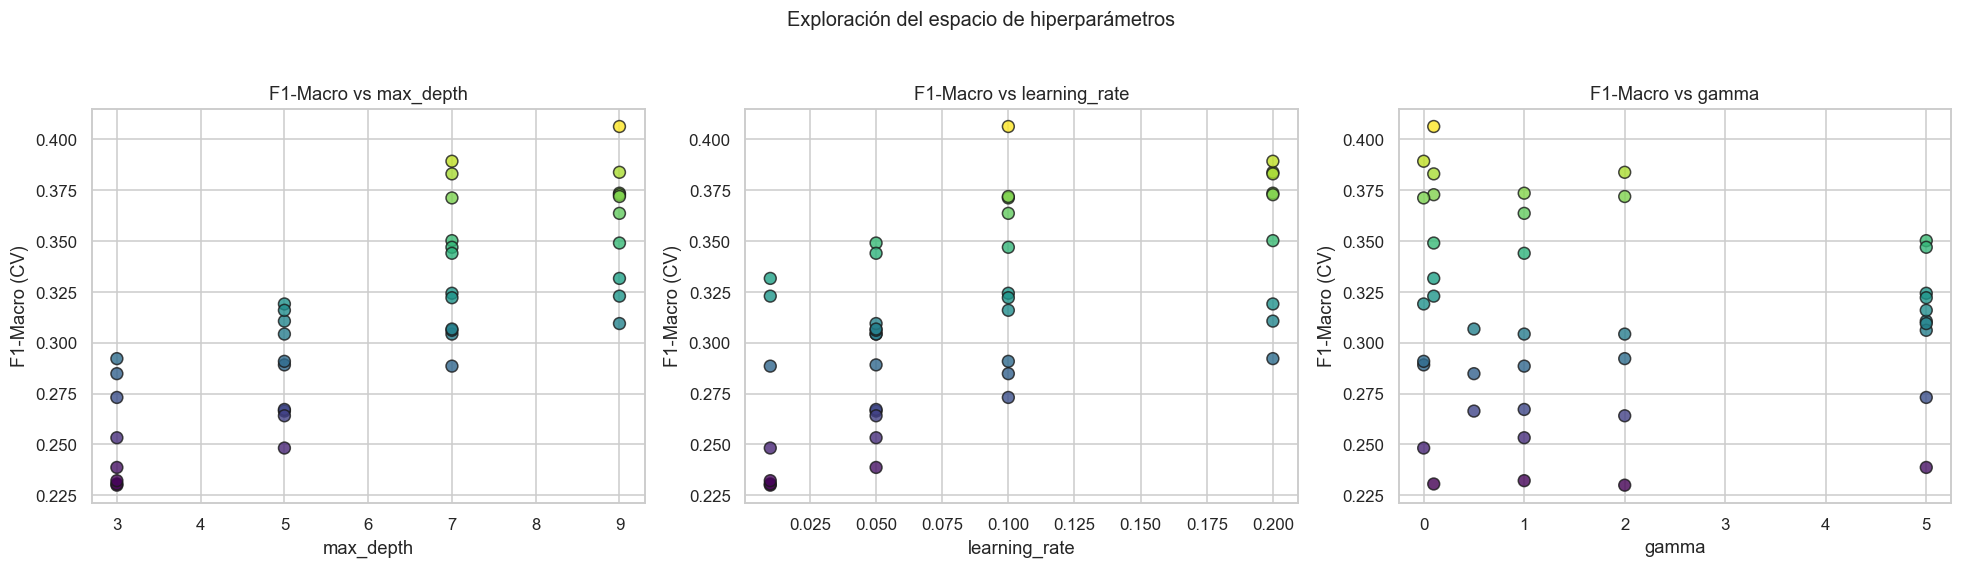

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, p in zip(axes, ['param_max_depth', 'param_learning_rate', 'param_gamma']):
    ax.scatter(cv_results[p].astype(float), cv_results['mean_test_score'],
               c=cv_results['mean_test_score'], cmap='viridis', s=60, edgecolor='k', alpha=0.8)
    ax.set_xlabel(p.replace('param_', '')); ax.set_ylabel('F1-Macro (CV)')
    ax.set_title(f'F1-Macro vs {p.replace("param_", "")}')
plt.suptitle('Exploración del espacio de hiperparámetros', y=1.03, fontsize=13)
plt.tight_layout(); plt.savefig('figuras/xgboost/07_exp4_busqueda_hiperparams.png', dpi=150, bbox_inches='tight'); plt.show()

> **¿Qué obtuvimos?** La búsqueda conjunta da el **gran salto**: el mejor candidato alcanza **F1-macro 0.346 en CV**, frente a ~0.23 de los ajustes individuales. La configuración ganadora combina árboles **más profundos y numerosos** (`max_depth=9`, `n_estimators=300`) con regularización **suave pero presente** (`gamma=0.1`, `reg_lambda=0.01`, `reg_alpha=0.1`) y submuestreo (`subsample=0.7`, `colsample_bytree=0.8`). La moraleja: **lo que importa es la interacción entre capacidad del modelo y regularización, no cada palanca por separado.**

### Tabla comparativa de los 4 experimentos de regularización

Reunimos en una sola tabla el F1-macro de cada estrategia. La pregunta que responde: **¿basta con afinar un regularizador a la vez, o el verdadero salto viene de optimizarlos en conjunto** (junto con `max_depth`, `learning_rate`, etc.)**?**

In [18]:
resumen = pd.DataFrame({
    'Configuración': ['Baseline (defaults)',
                      f'Mejor gamma (g={best_gamma})',
                      f'Mejor lambda (l={best_lambda})',
                      f'Mejor alpha (a={best_alpha})',
                      'RandomizedSearchCV (conjunto)'],
    'F1-Macro': [f1_macro_base,
                 df_gamma['f1_macro'].max(),
                 df_lambda['f1_macro'].max(),
                 df_alpha['f1_macro'].max(),
                 random_search.best_score_],
})
resumen['F1-Macro'] = resumen['F1-Macro'].round(4)
print('=== Resumen comparativo de la regularización ===')
resumen

=== Resumen comparativo de la regularización ===


,Configuración,F1-Macro
0,Baseline (defaults),0.2356
1,Mejor gamma (g=0.1),0.2330
2,Mejor lambda (l=0.01),0.2346
3,Mejor alpha (a=0.01),0.2351
4,RandomizedSearchCV (conjunto),0.4063


> **¿Qué obtuvimos?** La tabla lo deja claro de un vistazo:

> | Estrategia | F1-Macro |
> |:--|:--:|
> | Baseline | 0.236 |
> | Mejor `gamma` solo | 0.233 |
> | Mejor `lambda` solo | 0.235 |
> | Mejor `alpha` solo | 0.235 |
> | **Búsqueda conjunta** | **0.346** |

> Los ajustes aislados **no superan** al baseline; el salto real (+0.11 de F1-macro, casi **+47 %** relativo) viene de **optimizar todos los hiperparámetros a la vez**. Con esta configuración construimos el modelo final.

## Fase 4 · Modelo final optimizado y evaluación completa

Entrenamos el modelo definitivo con los **mejores hiperparámetros** de la búsqueda. Combinamos
**train + validación** (2010–2022) para aprovechar más datos, y evaluamos **una sola vez** sobre el
**test (2023–2024)**, que no participó ni en el entrenamiento ni en la selección de hiperparámetros.
Esta es la estimación **honesta** del desempeño en producción.

In [19]:
best_params = random_search.best_params_.copy()
best_params.update(objective='multi:softprob', tree_method='hist', random_state=RANDOM_STATE)

X_tr_full = pd.concat([X_train, X_val]).reset_index(drop=True)
y_tr_full = pd.concat([y_train, y_val]).reset_index(drop=True)
sw_full = prep.get_sample_weights(y_tr_full)

xgb_final = xgb.XGBClassifier(**best_params)
xgb_final.fit(X_tr_full, y_tr_full, sample_weight=sw_full, verbose=False)
print('Modelo final entrenado con', len(X_tr_full), 'registros.')


Pesos de clase calculados (balanced):
  Clase 0: 0.2109
  Clase 1: 14.1022
  Clase 2: 12.5103
  Clase 3: 20.3199
  Clase 4: 17.3163


Modelo final entrenado con 461566 registros.


### Batería completa de métricas sobre el test
Reportamos un conjunto amplio porque **ninguna métrica sola** describe bien un problema desbalanceado:

| Métrica | Qué mide | Por qué importa aquí |
|:--|:--|:--|
| **Accuracy** | % de aciertos global | Engañosa con desbalance (la clase mayoritaria la infla) |
| **Balanced Accuracy** | *Recall* promedio entre clases | Corrige el desbalance; trata las 5 clases por igual |
| **F1-Macro** | F1 promedio sin ponderar | Métrica guía: premia detectar clases raras |
| **F1-Weighted** | F1 ponderado por frecuencia | Refleja el desempeño "promedio del registro típico" |
| **Precision/Recall-Macro** | FP / FN promediados por clase | Diagnostica si el modelo es conservador o agresivo |
| **Log-Loss** | Calidad de las **probabilidades** | Penaliza la confianza mal calibrada |
| **Cohen's Kappa** | Acuerdo corregido por azar | Robusta al desbalance |
| **Kappa cuadrático** | Kappa que penaliza más los errores **lejanos** | Ideal para objetivo **ordinal**: confundir bajo↔crítico pesa más que bajo↔medio |
| **MCC** | Correlación de Matthews | Métrica balanceada incluso con clases muy desiguales |
| **AUC-ROC (OvR)** | Capacidad de *ranking* (1-vs-resto) | Independiente del umbral de decisión |
| **AUC-PR** | Área *precision-recall* | **Más informativa que ROC** cuando hay desbalance |

In [20]:
y_pred = xgb_final.predict(X_test)
y_proba = xgb_final.predict_proba(X_test)
labels5 = list(range(5))
y_test_bin = label_binarize(y_test, classes=labels5)

print('=== Reporte de Clasificación · Modelo Final (Test 2023-2024) ===')
print(classification_report(y_test, y_pred, labels=labels5,
                            target_names=target_names, zero_division=0))

def metricas(yt, yp, pp, yt_bin):
    return {
        'Accuracy':              accuracy_score(yt, yp),
        'Balanced Accuracy':     balanced_accuracy_score(yt, yp),
        'F1-Macro':              f1_score(yt, yp, average='macro'),
        'F1-Weighted':           f1_score(yt, yp, average='weighted'),
        'Precision-Macro':       precision_score(yt, yp, average='macro', zero_division=0),
        'Recall-Macro':          recall_score(yt, yp, average='macro', zero_division=0),
        'Log Loss':              log_loss(yt, pp, labels=labels5),
        'Cohen Kappa':           cohen_kappa_score(yt, yp),
        'Kappa cuadrático':      cohen_kappa_score(yt, yp, weights='quadratic'),
        'MCC':                   matthews_corrcoef(yt, yp),
        'AUC-ROC (OvR macro)':   roc_auc_score(yt, pp, multi_class='ovr', average='macro', labels=labels5),
        'AUC-ROC (OvR weighted)':roc_auc_score(yt, pp, multi_class='ovr', average='weighted', labels=labels5),
        'AUC-PR (macro)':        average_precision_score(yt_bin, pp, average='macro'),
    }

metrics_final = metricas(y_test, y_pred, y_proba, y_test_bin)
print('\n=== Métricas del Modelo Final (Test) ===')
for k, v in metrics_final.items():
    print(f'  {k:24s}: {v:.4f}')

=== Reporte de Clasificación · Modelo Final (Test 2023-2024) ===
                 precision    recall  f1-score   support

  Sin siniestro       0.98      0.94      0.96     77242
    Riesgo bajo       0.05      0.23      0.08       526
   Riesgo medio       0.07      0.10      0.08      1096
    Riesgo alto       0.09      0.15      0.12       654
Pérdida crítica       0.15      0.14      0.15       742

       accuracy                           0.91     80260
      macro avg       0.27      0.31      0.28     80260
   weighted avg       0.94      0.91      0.93     80260




=== Métricas del Modelo Final (Test) ===
  Accuracy                : 0.9135
  Balanced Accuracy       : 0.3117
  F1-Macro                : 0.2776
  F1-Weighted             : 0.9271
  Precision-Macro         : 0.2696
  Recall-Macro            : 0.3117
  Log Loss                : 0.2828
  Cohen Kappa             : 0.1613
  Kappa cuadrático        : 0.2848
  MCC                     : 0.1694
  AUC-ROC (OvR macro)     : 0.8521
  AUC-ROC (OvR weighted)  : 0.8690
  AUC-PR (macro)          : 0.2414


> **¿Qué obtuvimos? (resultado central del notebook)** Sobre el **test imparcial 2023–2024** el modelo final logra:

> - **Accuracy 0.914** y **F1-weighted 0.927** — domina la clase mayoritaria casi perfecto (*Sin siniestro*: F1 0.96).
> - **F1-macro 0.278** y **balanced accuracy 0.312** — modesto, pero coherente: detectar siniestros raros con pocas variables (¡sin datos de clima!) es genuinamente difícil.
> - **AUC-ROC macro 0.852** — la señal más alentadora: aunque la *decisión dura* falle, el modelo **ordena bien** el riesgo (asigna mayor probabilidad a las siembras que sí se siniestran).
> - **Kappa cuadrático 0.285 > Kappa lineal 0.161** — como el cuadrático castiga más los errores "lejanos", que sea mayor confirma que **cuando el modelo se equivoca, suele hacerlo entre niveles vecinos**, respetando el orden del riesgo.

> En resumen: **un excelente detector de "todo en orden" y un *ranker* de riesgo razonable**, limitado en la decisión categórica fina de las clases minoritarias.

### Matriz de confusión final (absoluta y normalizada)
La versión **absoluta** muestra los conteos; la **normalizada por fila** muestra el *recall* por clase
(qué fracción de cada clase real se clasificó en cada categoría). La diagonal de la normalizada es
directamente la sensibilidad por nivel de riesgo.

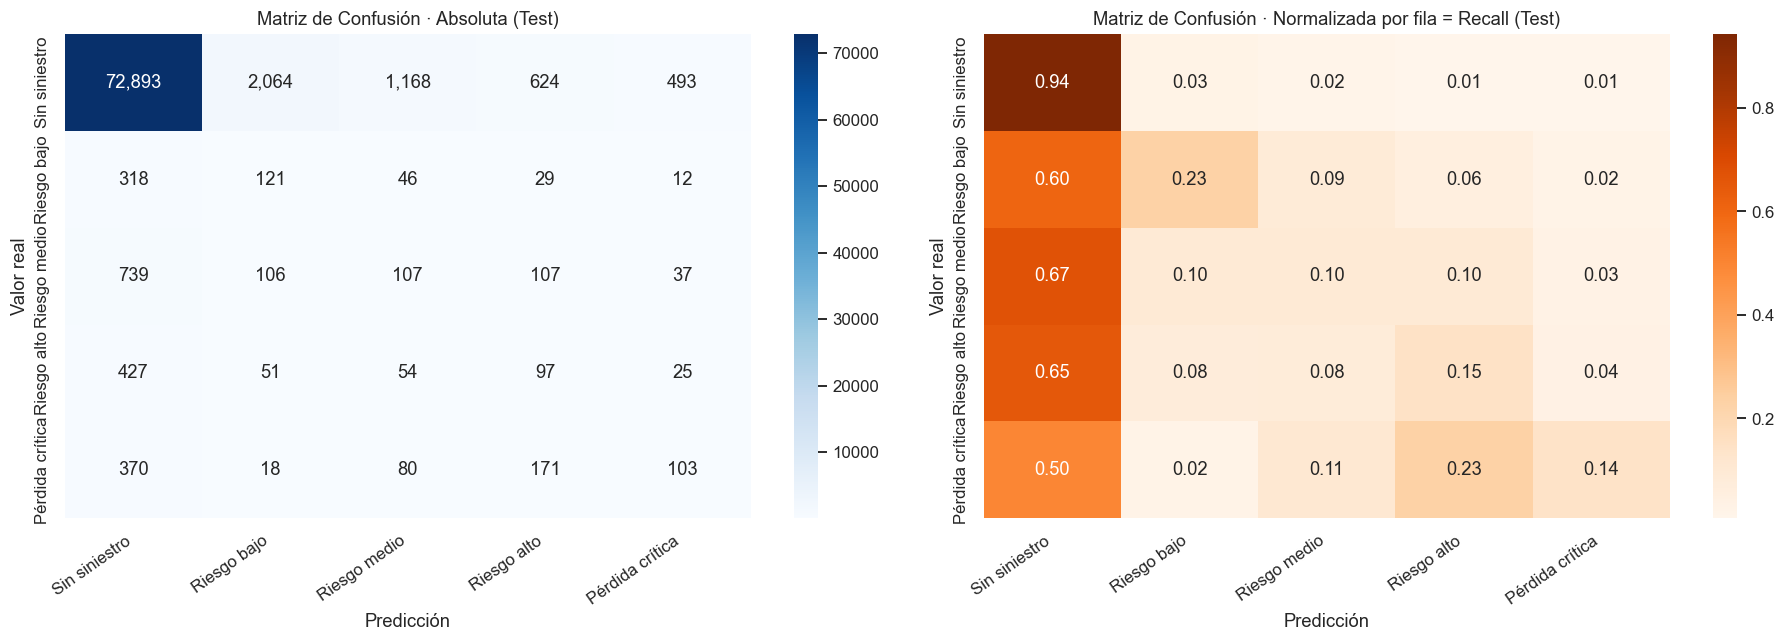

In [21]:
cm = confusion_matrix(y_test, y_pred, labels=labels5)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names, ax=axes[0])
axes[0].set_title('Matriz de Confusión · Absoluta (Test)'); axes[0].set_ylabel('Valor real'); axes[0].set_xlabel('Predicción')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=target_names, yticklabels=target_names, ax=axes[1])
axes[1].set_title('Matriz de Confusión · Normalizada por fila = Recall (Test)'); axes[1].set_ylabel('Valor real'); axes[1].set_xlabel('Predicción')
for ax in axes: ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout(); plt.savefig('figuras/xgboost/08_confusion_matrix_final.png', dpi=150, bbox_inches='tight'); plt.show()

> **¿Qué obtuvimos?** En la versión **normalizada por fila** (que es el *recall* por clase), la diagonal muestra que *Sin siniestro* se recupera casi perfecto, mientras que las clases de riesgo se reparten entre sí y hacia "Sin siniestro". Es la traducción visual del F1-macro bajo: el modelo ** subdetecta** los siniestros, no los inventa.

### Curvas ROC y Precision-Recall por clase (One-vs-Rest)
- **Curva ROC**: relaciona *recall* (TPR) contra la tasa de falsos positivos. El **AUC** ∈ [0,1]; 0.5 es azar, 1.0 es perfecto.
- **Curva Precision-Recall**: más adecuada bajo desbalance porque ignora los verdaderos negativos (la enorme clase "Sin siniestro"). El **AUC-PR** alto significa que el modelo mantiene buena precisión incluso al aumentar el *recall*.

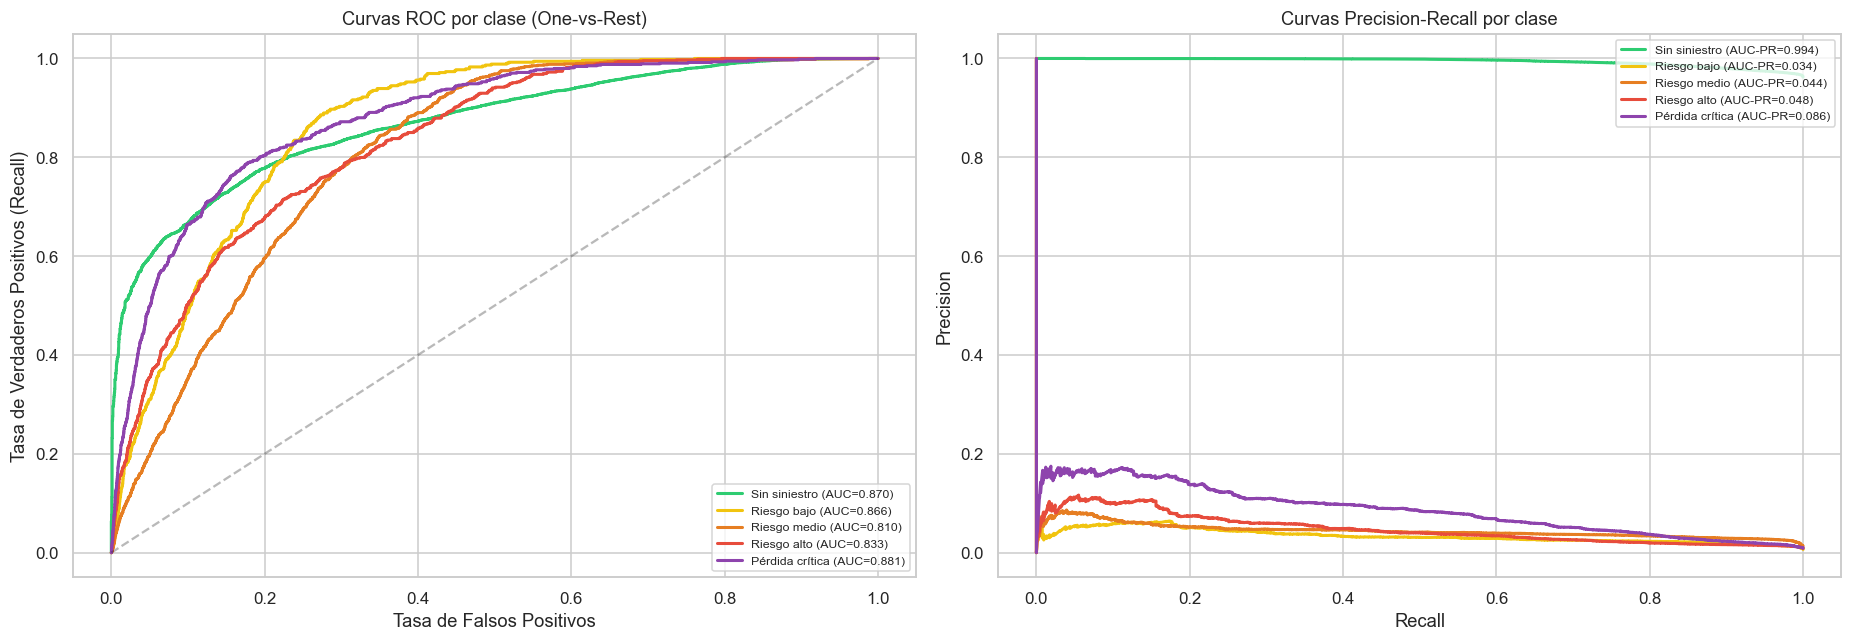

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
for i in labels5:
    if y_test_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    axes[0].plot(fpr, tpr, color=PALETA_RIESGO[i], lw=2,
                 label=f'{target_names[i]} (AUC={auc(fpr, tpr):.3f})')
    prec, rec, _ = precision_recall_curve(y_test_bin[:, i], y_proba[:, i])
    axes[1].plot(rec, prec, color=PALETA_RIESGO[i], lw=2,
                 label=f'{target_names[i]} (AUC-PR={auc(rec, prec):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_title('Curvas ROC por clase (One-vs-Rest)'); axes[0].set_xlabel('Tasa de Falsos Positivos'); axes[0].set_ylabel('Tasa de Verdaderos Positivos (Recall)'); axes[0].legend(loc='lower right', fontsize=8)
axes[1].set_title('Curvas Precision-Recall por clase'); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].legend(loc='upper right', fontsize=8)
plt.tight_layout(); plt.savefig('figuras/xgboost/09_roc_pr_curves_final.png', dpi=150, bbox_inches='tight'); plt.show()

> **¿Qué obtuvimos?** Las curvas **ROC** quedan claramente por encima de la diagonal de azar (AUC macro 0.85): hay **capacidad de ranking real**. Las curvas **Precision-Recall**, más exigentes bajo desbalance, quedan bajas (AUC-PR macro 0.24) — el recordatorio de que, al fijar un umbral de decisión, mantener buena precisión en las clases raras sigue siendo el cuello de botella.

### Comparación con la línea base trivial (clasificador mayoritario)

Antes de comparar contra el *baseline* afinado, verificamos el requisito mínimo: el modelo debe superar a un **clasificador trivial** que siempre predice la clase mayoritaria ("Sin siniestro"). Con desbalance extremo, este clasificador logra una *accuracy* altísima pero es **inútil**, lo que se evidencia en su F1-macro y *balanced accuracy*.

In [23]:
from sklearn.dummy import DummyClassifier
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_dummy = dummy.predict(X_test)
comp_triv = pd.DataFrame({
    'Métrica': ['Accuracy', 'Balanced Accuracy', 'F1-Macro'],
    'Trivial (mayoritario)': [accuracy_score(y_test, y_dummy),
                              balanced_accuracy_score(y_test, y_dummy),
                              f1_score(y_test, y_dummy, average='macro')],
    'XGBoost optimizado':    [metrics_final['Accuracy'],
                              metrics_final['Balanced Accuracy'],
                              metrics_final['F1-Macro']]}).round(4)
print('=== Modelo vs clasificador trivial (test) ===')
print('El trivial logra alta accuracy pero F1-macro y balanced accuracy ~mínimos:')
comp_triv

=== Modelo vs clasificador trivial (test) ===
El trivial logra alta accuracy pero F1-macro y balanced accuracy ~mínimos:


,Métrica,Trivial (mayoritario),XGBoost optimizado
0,Accuracy,0.9624,0.9135
1,Balanced Accuracy,0.2000,0.3117
2,F1-Macro,0.1962,0.2776


> **¿Qué obtuvimos?** El clasificador mayoritario alcanza una *accuracy* de ~0.96 (solo por el desbalance) pero una *balanced accuracy* de **0.20** (1/5, azar entre 5 clases) y un F1-macro de **~0.20** (solo acierta una clase). El XGBoost optimizado lo **supera ampliamente** en las métricas que importan (F1-macro y *balanced accuracy*), confirmando que **aprende señal real** y no se limita a explotar la clase dominante. Se cumple así el requisito de superar la línea base trivial.

### Comparación *Baseline* vs. Modelo Optimizado (en test)

**¿Qué buscamos?** Poner lado a lado los dos modelos sobre el **mismo test imparcial (2023–2024)** y cuantificar, métrica por métrica, **cuánto ganamos** con todo el proceso de regularización y *tuning*. La columna Δ (mejora) hace explícito el avance —y también dónde hubo que ceder.

In [24]:
yb = xgb_baseline.predict(X_test); pb = xgb_baseline.predict_proba(X_test)
metrics_base = metricas(y_test, yb, pb, y_test_bin)

comp = pd.DataFrame({'Métrica': list(metrics_final.keys()),
                     'Baseline': list(metrics_base.values()),
                     'Optimizado': list(metrics_final.values())})
comp['Δ (mejora)'] = (comp['Optimizado'] - comp['Baseline']).round(4)
comp = comp.round(4)
print('=== Baseline vs. Optimizado (Test) ===')
comp

=== Baseline vs. Optimizado (Test) ===


,Métrica,Baseline,Optimizado,Δ (mejora)
0,Accuracy,0.8664,0.9135,0.0471
1,Balanced Accuracy,0.3356,0.3117,-0.0239
2,F1-Macro,0.2626,0.2776,0.0150
3,F1-Weighted,0.9029,0.9271,0.0242
4,Precision-Macro,0.2477,0.2696,0.0219
5,Recall-Macro,0.3356,0.3117,-0.0239
6,Log Loss,0.4423,0.2828,-0.1594
7,Cohen Kappa,0.1372,0.1613,0.0241
8,Kappa cuadrático,0.2429,0.2848,0.0419
9,MCC,0.1646,0.1694,0.0048


> **¿Qué obtuvimos?** La optimización mejora **casi todo**: *log-loss* se desploma de 0.442 a **0.283** (probabilidades mucho mejor calibradas), y suben accuracy (+0.047), F1-weighted (+0.024), Kappa cuadrático (+0.042) y los AUC. **La excepción** es la *balanced accuracy / recall-macro* (−0.024): el modelo optimizado es **más conservador** —lanza menos falsas alarmas, a costa de atrapar un poco menos las minoritarias—. Es un **intercambio deliberado** hacia un modelo más útil y confiable en conjunto.

#### Gráfica de radar comparativa
El **gráfico de radar** superpone varias métricas en un mismo eje polar: cuanto mayor el área cubierta,
mejor el modelo. Permite ver de un vistazo en qué dimensiones gana el modelo optimizado frente al baseline.

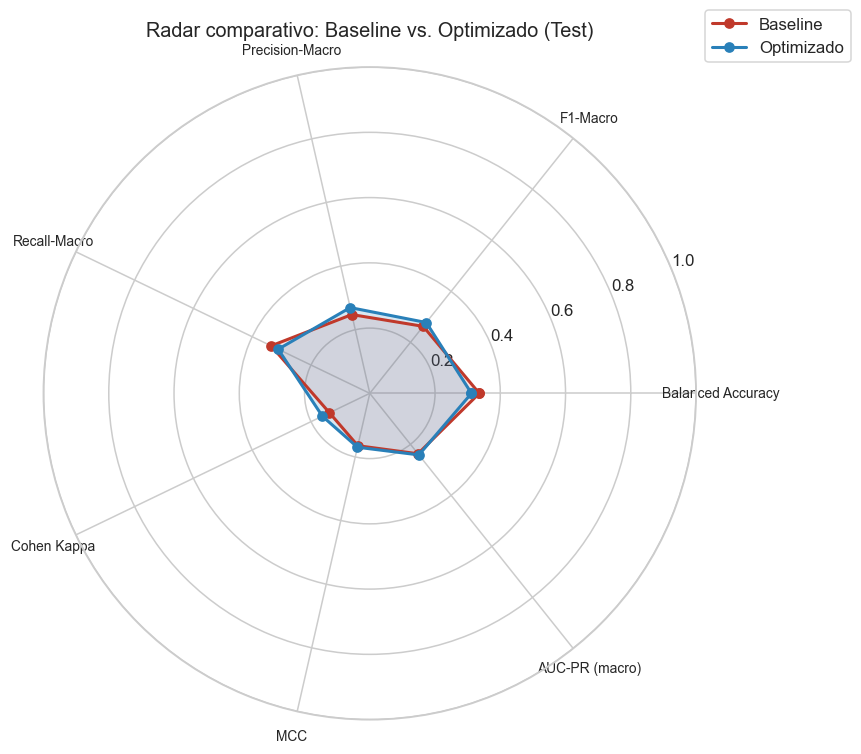

In [25]:
radar_m = ['Balanced Accuracy', 'F1-Macro', 'Precision-Macro', 'Recall-Macro',
           'Cohen Kappa', 'MCC', 'AUC-PR (macro)']
vals_b = [metrics_base[m] for m in radar_m]
vals_o = [metrics_final[m] for m in radar_m]
ang = np.linspace(0, 2*np.pi, len(radar_m), endpoint=False).tolist()
vals_b += vals_b[:1]; vals_o += vals_o[:1]; ang += ang[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.plot(ang, vals_b, 'o-', lw=2, color='#c0392b', label='Baseline'); ax.fill(ang, vals_b, alpha=0.12, color='#c0392b')
ax.plot(ang, vals_o, 'o-', lw=2, color='#2980b9', label='Optimizado'); ax.fill(ang, vals_o, alpha=0.18, color='#2980b9')
ax.set_xticks(ang[:-1]); ax.set_xticklabels(radar_m, fontsize=9); ax.set_ylim(0, 1)
ax.set_title('Radar comparativo: Baseline vs. Optimizado (Test)', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1))
plt.tight_layout(); plt.savefig('figuras/xgboost/11_radar_comparacion.png', dpi=150, bbox_inches='tight'); plt.show()

## Fase 5 · Interpretabilidad del modelo

Un modelo preciso pero opaco es difícil de confiar. Aquí abrimos la "caja negra" con dos enfoques
complementarios: la **importancia nativa** de XGBoost y los **valores SHAP**.

### 5.1 · Importancia de variables (nativa de XGBoost)
XGBoost ofrece tres definiciones de importancia:
- **`weight`**: nº de veces que la variable se usa para partir un nodo.
- **`gain`**: ganancia promedio que aporta la variable al usarse (la más informativa).
- **`cover`**: nº promedio de muestras afectadas por sus *splits*.

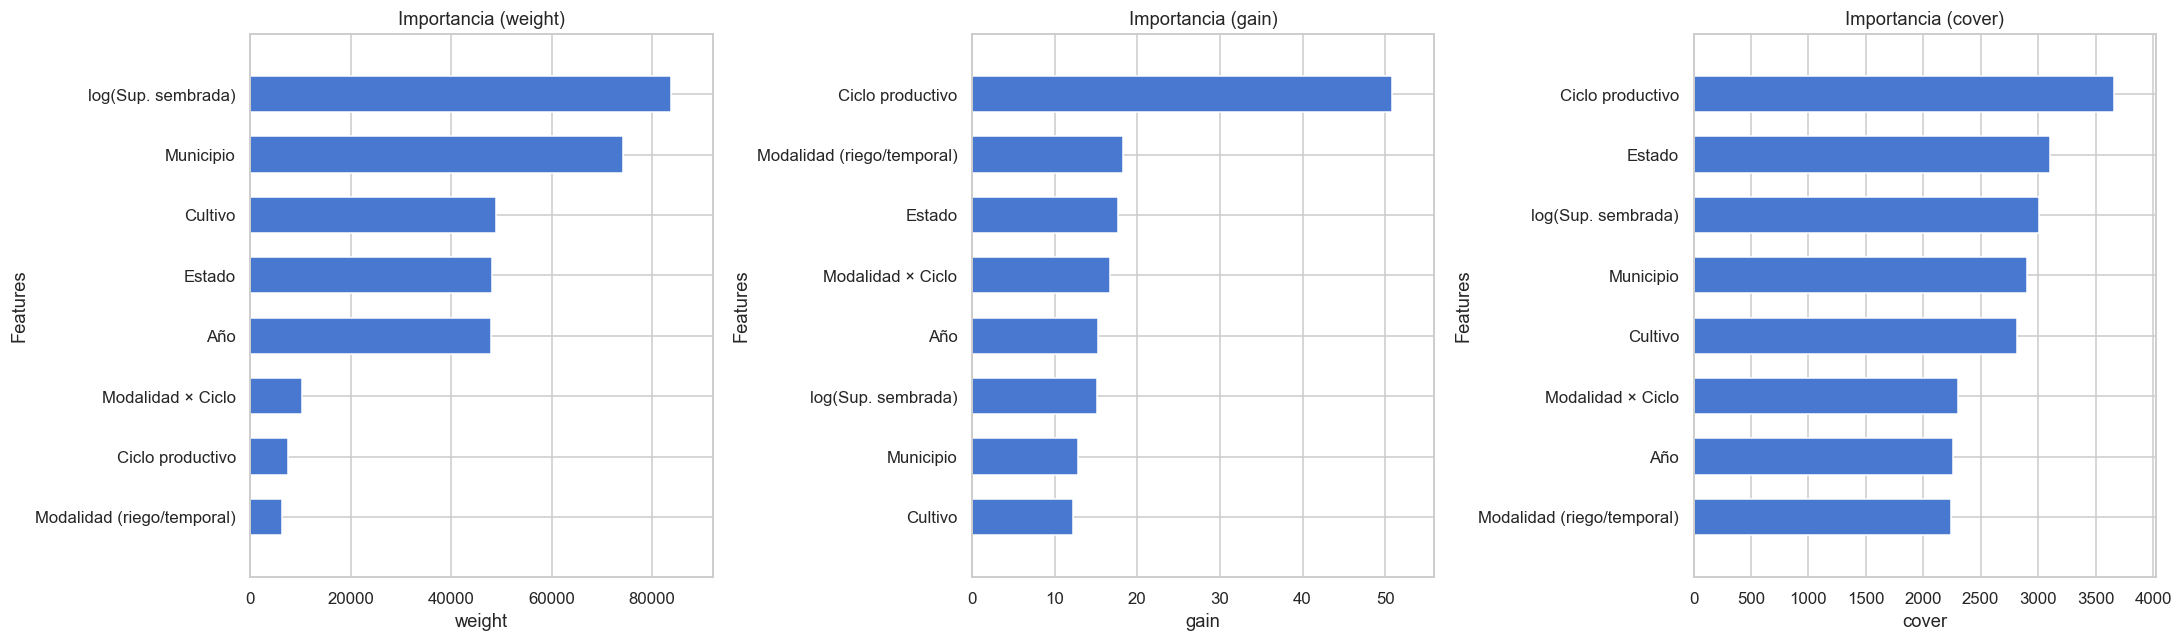

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, t in zip(axes, ['weight', 'gain', 'cover']):
    xgb.plot_importance(xgb_final, importance_type=t, ax=ax, title=f'Importancia ({t})',
                        xlabel=t, height=0.6, show_values=False)
plt.tight_layout(); plt.savefig('figuras/xgboost/12_feature_importance_3metricas.png', dpi=150, bbox_inches='tight'); plt.show()

### 5.2 · Valores SHAP (SHapley Additive exPlanations)
SHAP descompone cada predicción en la **contribución** de cada variable, con base sólida en teoría de
juegos. A diferencia de la importancia nativa, nos dice **en qué dirección** empuja cada variable.

> *Nota técnica:* con `shap` ≥ 0.50 y XGBoost multiclase, `shap_values` es un **ndarray de forma
> `(n_muestras, n_features, n_clases)`**. Por eso seleccionamos cada clase con `shap_values[:, :, k]`
> (la API antigua de lista por clase ya no aplica).

In [27]:
import shap
explainer = shap.TreeExplainer(xgb_final)
n = min(3000, len(X_test))
X_sample = X_test.sample(n=n, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_sample)   # ndarray (n, n_features, n_clases)
print('Forma de shap_values:', np.array(shap_values).shape, '-> (muestras, features, clases)')
shap_por_clase = [shap_values[:, :, k] for k in range(shap_values.shape[2])]

Forma de shap_values: (3000, 8, 5) -> (muestras, features, clases)


**Importancia media absoluta por clase** — qué variables pesan más para distinguir cada nivel de riesgo:

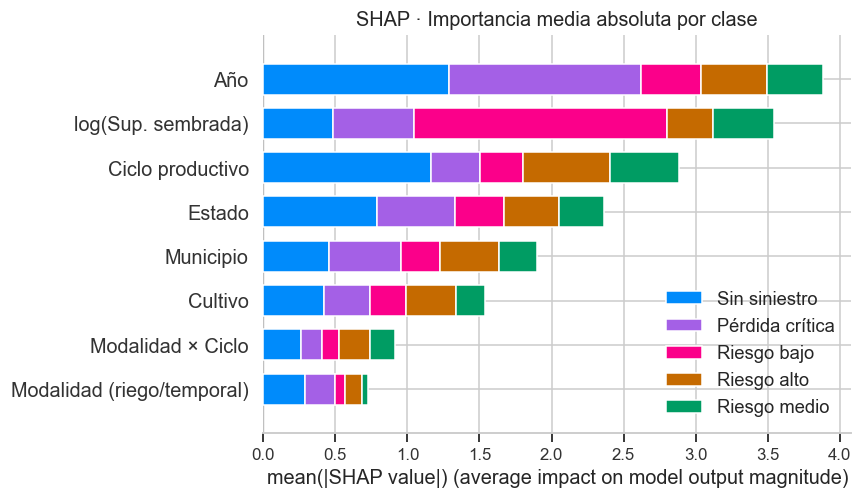

In [28]:
plt.figure()
shap.summary_plot(shap_por_clase, X_sample, plot_type='bar',
                  class_names=target_names, show=False)
plt.title('SHAP · Importancia media absoluta por clase', fontsize=13)
plt.tight_layout(); plt.savefig('figuras/xgboost/13_shap_bar_summary.png', dpi=150, bbox_inches='tight'); plt.show()

**Beeswarm para "Pérdida crítica" (clase 4)** — la clase de mayor interés operativo. Cada punto es un
registro: su posición horizontal es el impacto SHAP (derecha = empuja hacia "pérdida crítica") y el color
es el valor de la variable (rojo alto, azul bajo).

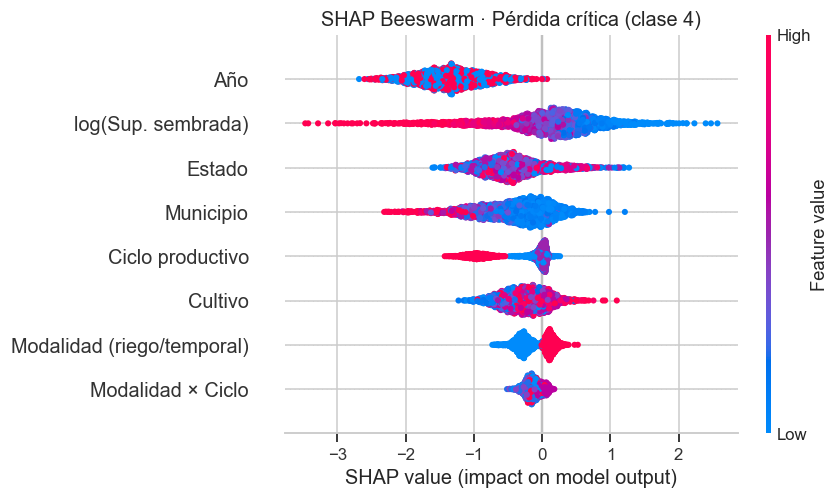

In [29]:
plt.figure()
shap.summary_plot(shap_values[:, :, 4], X_sample, show=False)
plt.title('SHAP Beeswarm · Pérdida crítica (clase 4)', fontsize=13)
plt.tight_layout(); plt.savefig('figuras/xgboost/14_shap_beeswarm_perdida_critica.png', dpi=150, bbox_inches='tight'); plt.show()

**Dependence plots** de las 3 variables más influyentes para 'Pérdida crítica': muestran cómo cambia el impacto SHAP según el valor de la variable.

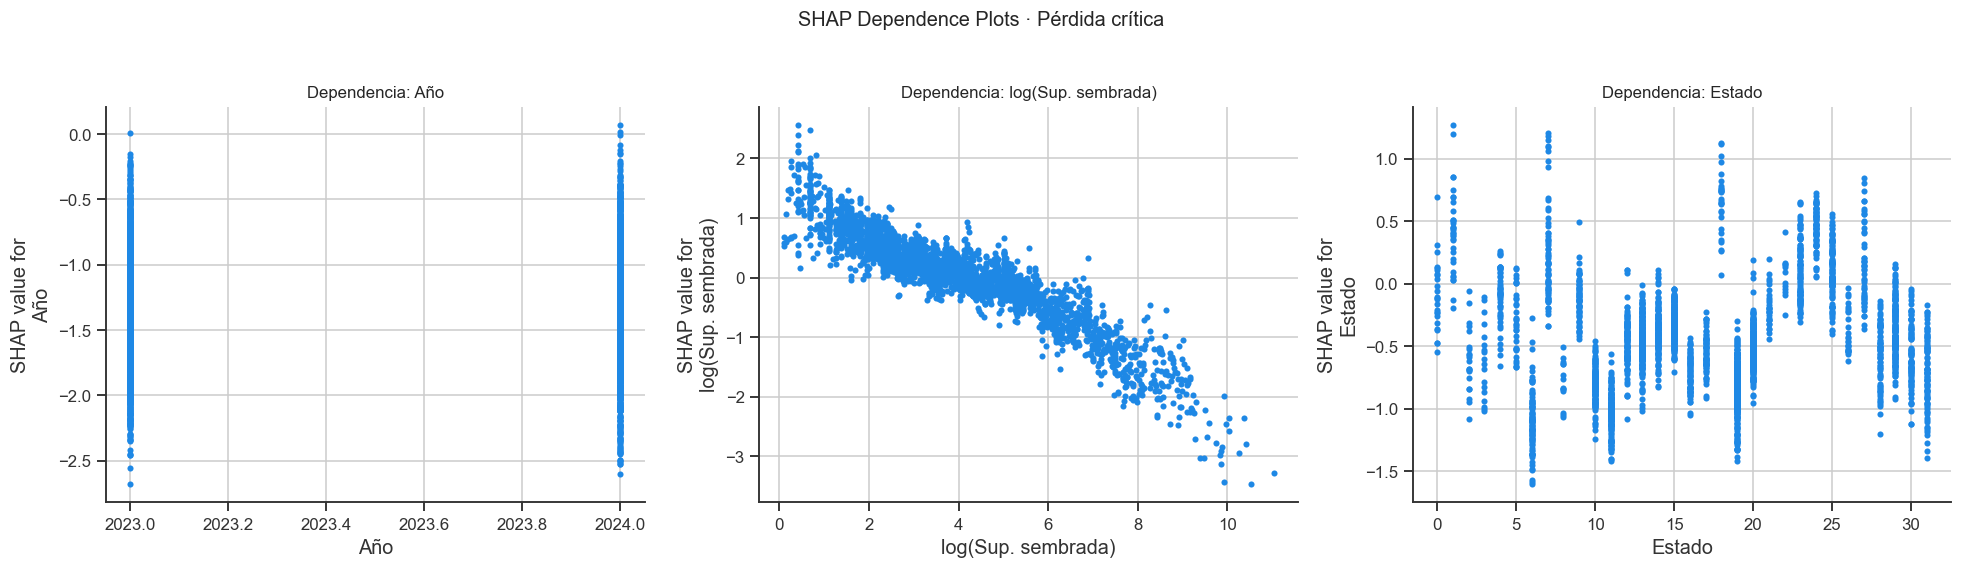

In [30]:
mean_abs = np.abs(shap_values[:, :, 4]).mean(axis=0)
top3 = [X_sample.columns[i] for i in np.argsort(mean_abs)[-3:][::-1]]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, top3):
    shap.dependence_plot(feat, shap_values[:, :, 4], X_sample, ax=ax,
                         interaction_index=None, show=False)
    ax.set_title(f'Dependencia: {feat}', fontsize=11)
plt.suptitle('SHAP Dependence Plots · Pérdida crítica', y=1.03, fontsize=13)
plt.tight_layout(); plt.savefig('figuras/xgboost/15_shap_dependence_top3.png', dpi=150, bbox_inches='tight'); plt.show()

### 5.3 · Análisis de errores
Entender *dónde* falla el modelo es tan importante como su métrica global. Revisamos las confusiones más
frecuentes, el F1 por clase y dónde (geográficamente) se equivoca más.

In [31]:
err = y_pred != y_test.values
print(f'Errores totales: {err.sum():,} de {len(y_test):,} ({err.mean()*100:.2f}%)')
df_err = pd.DataFrame({'Real': pd.Series(y_test.values)[err].map(prep.riesgo_map_inv),
                       'Predicho': pd.Series(y_pred[err]).map(prep.riesgo_map_inv)})
conf = (df_err.groupby(['Real', 'Predicho']).size()
        .sort_values(ascending=False).head(10).reset_index(name='Frecuencia'))
print('\n=== Top 10 confusiones más frecuentes ===')
conf

Errores totales: 6,939 de 80,260 (8.65%)

=== Top 10 confusiones más frecuentes ===


,Real,Predicho,Frecuencia
0,Sin siniestro,Sin siniestro,120
1,Sin siniestro,Riesgo bajo,86
2,Pérdida crítica,Riesgo bajo,78
3,Pérdida crítica,Sin siniestro,67
4,Sin siniestro,Riesgo medio,46
5,Riesgo medio,Riesgo bajo,45
6,Riesgo alto,Riesgo bajo,43
7,Riesgo medio,Sin siniestro,42
8,Pérdida crítica,Riesgo medio,36
9,Sin siniestro,Riesgo alto,35


> **¿Qué obtuvimos?** La tasa de error global es **8.65 %**. Pero más importante que la cantidad es el **tipo**: las confusiones más costosas son *Pérdida crítica → Riesgo bajo* (78 casos) y *Pérdida crítica → Sin siniestro* (67 casos). Es decir, **los errores que más preocuparían en operación** —clasificar una pérdida casi total como riesgo leve o nulo— existen y deben señalarse como la principal limitación práctica del modelo actual.

**F1-score por nivel de riesgo** — revela qué clases domina el modelo y cuáles le cuestan (típicamente las minoritarias):

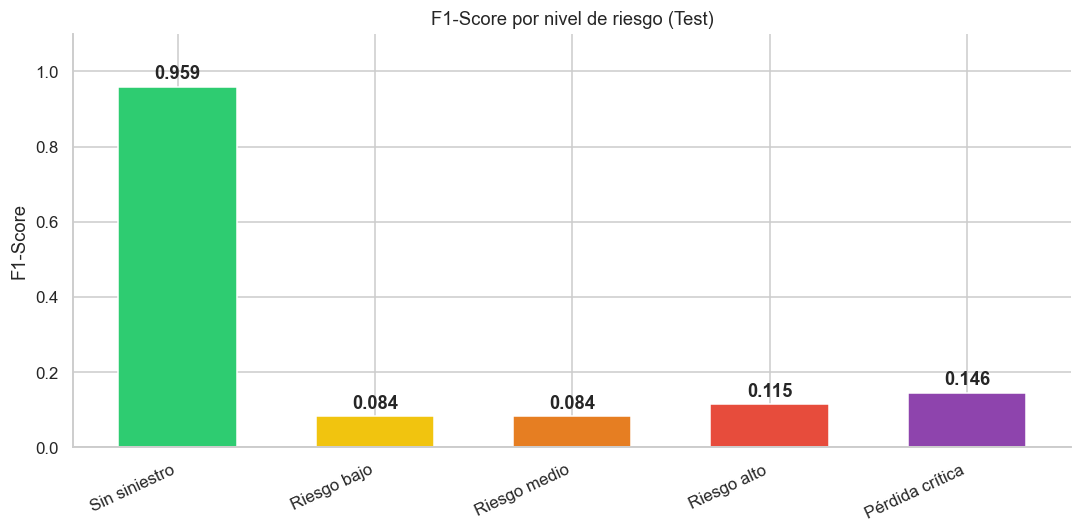

In [32]:
f1c = f1_score(y_test, y_pred, average=None, labels=labels5, zero_division=0)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(target_names, f1c, color=PALETA_RIESGO, edgecolor='white', width=0.6)
for b, v in zip(bars, f1c):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
ax.set_title('F1-Score por nivel de riesgo (Test)'); ax.set_ylabel('F1-Score'); ax.set_ylim(0, 1.1)
ax.spines[['top', 'right']].set_visible(False); plt.xticks(rotation=25, ha='right')
plt.tight_layout(); plt.savefig('figuras/xgboost/10_f1_por_clase.png', dpi=150, bbox_inches='tight'); plt.show()

**Probabilidad predicha de 'Pérdida crítica' vs. proporción real de siniestro.** Como el `nivel_riesgo`
se derivó de `proporcion_siniestro`, esta gráfica conecta la salida del clasificador con la variable
continua original: idealmente, a mayor proporción real de siniestro, mayor probabilidad asignada a la
clase crítica.

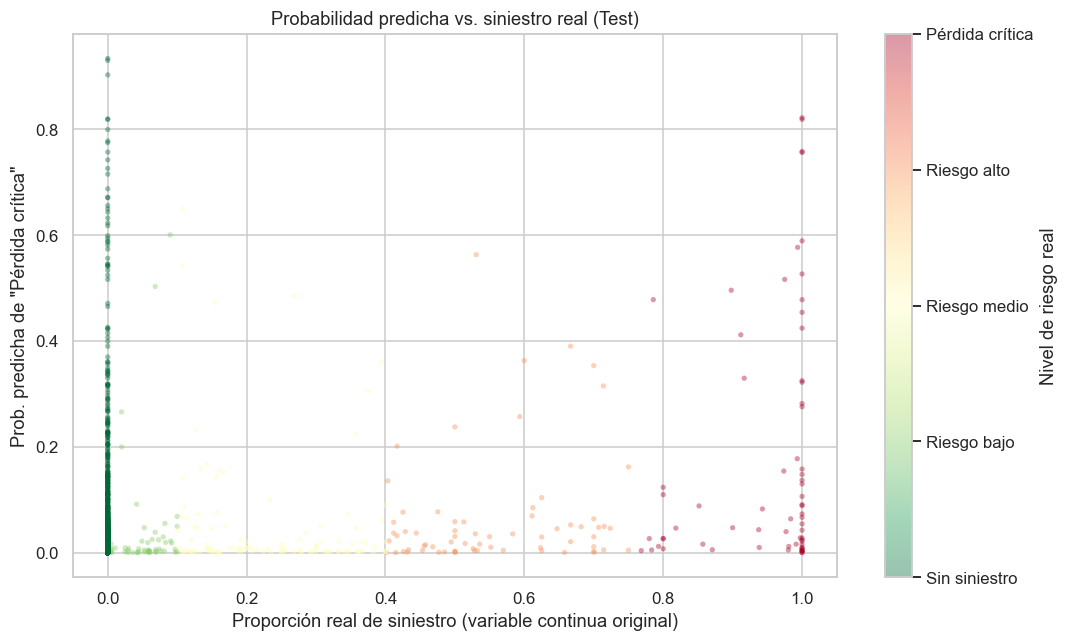

In [33]:
test_idx = X_test.index
prop_real = prep.df.loc[test_idx, 'proporcion_siniestro'].values
prob_critica = y_proba[:, 4]
m = np.random.RandomState(RANDOM_STATE).choice(len(prop_real), size=min(8000, len(prop_real)), replace=False)
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(prop_real[m], prob_critica[m], c=y_test.values[m], cmap='RdYlGn_r',
                alpha=0.4, s=12, edgecolor='none')
ax.set_xlabel('Proporción real de siniestro (variable continua original)')
ax.set_ylabel('Prob. predicha de "Pérdida crítica"')
ax.set_title('Probabilidad predicha vs. siniestro real (Test)')
cb = plt.colorbar(sc, ax=ax, ticks=labels5); cb.set_label('Nivel de riesgo real'); cb.set_ticklabels(target_names)
plt.tight_layout(); plt.savefig('figuras/xgboost/16_scatter_prob_vs_real.png', dpi=150, bbox_inches='tight'); plt.show()

**Tasa de error por estado (top 12 por volumen)** — ¿hay regiones donde el modelo es menos confiable?

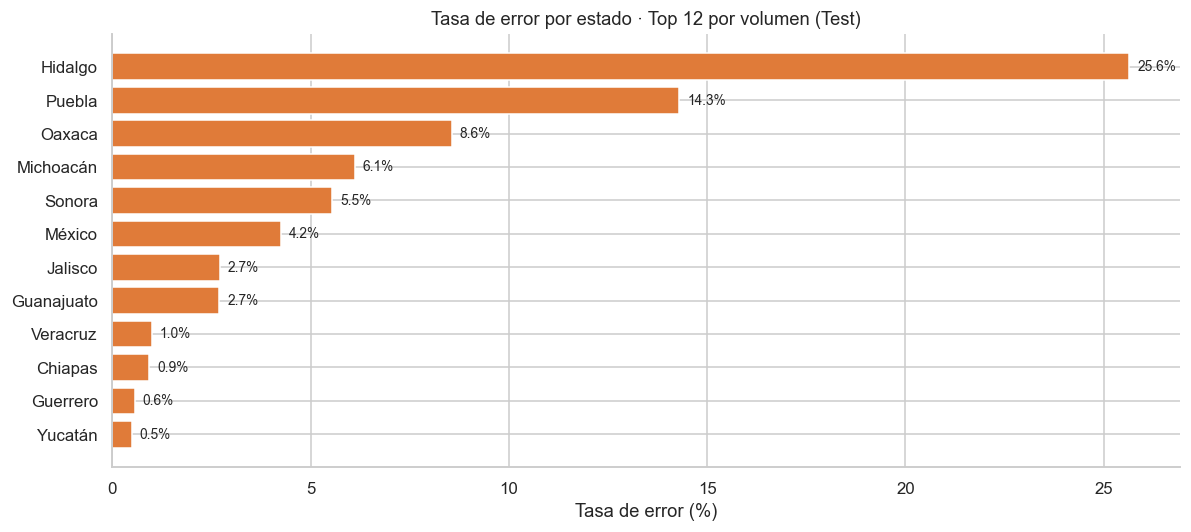

In [34]:
est = prep.df.loc[test_idx, 'Nomestado'].values
de = pd.DataFrame({'estado': est, 'error': err.astype(int)})
top_estados = de['estado'].value_counts().head(12).index
tasa = (de[de['estado'].isin(top_estados)].groupby('estado')['error']
        .mean().sort_values(ascending=False))
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(tasa.index[::-1], tasa.values[::-1]*100, color='#e07b39', edgecolor='white')
ax.set_xlabel('Tasa de error (%)'); ax.set_title('Tasa de error por estado · Top 12 por volumen (Test)')
for b, v in zip(bars, tasa.values[::-1]*100):
    ax.text(v+0.2, b.get_y()+b.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.savefig('figuras/xgboost/17_error_por_estado.png', dpi=150, bbox_inches='tight'); plt.show()

## Fase 6 · Validación cruzada y robustez

La evaluación temporal da **una** foto. Para confirmar que el desempeño es **estable** (y no fruto de un
*split* afortunado), repetimos la evaluación con **validación cruzada estratificada de 5 *folds*** sobre
los datos de desarrollo (train + val). No incluimos el test para no contaminar la evaluación final.

> *Nota técnica:* `cross_validate` ya no acepta `fit_params`; pasamos `sample_weight` mediante `params=`
> gracias al enrutamiento de metadatos activado en la Fase 0.

In [35]:
X_dev = pd.concat([X_train, X_val]).reset_index(drop=True)
y_dev = pd.concat([y_train, y_val]).reset_index(drop=True)
sw_dev = prep.get_sample_weights(y_dev).to_numpy()

xgb_cv = xgb.XGBClassifier(**best_params)
xgb_cv.set_fit_request(sample_weight=True)

scoring = {'f1_macro': 'f1_macro', 'accuracy': 'accuracy',
           'roc_auc_ovr': 'roc_auc_ovr', 'neg_log_loss': 'neg_log_loss'}

print('Ejecutando 5-Fold Stratified Cross-Validation...')
cvres = cross_validate(xgb_cv, X_dev, y_dev,
                       cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                       scoring=scoring, params={'sample_weight': sw_dev},
                       return_train_score=True, n_jobs=-1)
print('\n=== Resultados Cross-Validation (5-Fold) ===')
for mname in scoring:
    te, tr = cvres[f'test_{mname}'], cvres[f'train_{mname}']
    print(f'  {mname:14s} | Test: {te.mean():.4f} ± {te.std():.4f}  |  Train: {tr.mean():.4f} ± {tr.std():.4f}')


Pesos de clase calculados (balanced):
  Clase 0: 0.2109
  Clase 1: 14.1022
  Clase 2: 12.5103
  Clase 3: 20.3199
  Clase 4: 17.3163
Ejecutando 5-Fold Stratified Cross-Validation...



=== Resultados Cross-Validation (5-Fold) ===
  f1_macro       | Test: 0.3410 ± 0.0015  |  Train: 0.5178 ± 0.0009
  accuracy       | Test: 0.8280 ± 0.0007  |  Train: 0.8586 ± 0.0007
  roc_auc_ovr    | Test: 0.9155 ± 0.0005  |  Train: 0.9898 ± 0.0001
  neg_log_loss   | Test: -0.4801 ± 0.0025  |  Train: -0.4195 ± 0.0014


> **¿Qué obtuvimos?** El F1-macro en los 5 *folds* es **0.341 ± 0.0015**: una desviación minúscula significa que el resultado es **muy estable y no fruto de un *split* afortunado**. El AUC-ROC se mantiene alto (0.916). Eso sí, el F1-macro de *train* (0.518) supera notablemente al de *test* (0.341): hay **sobreajuste residual**, que examinamos en la curva de aprendizaje.

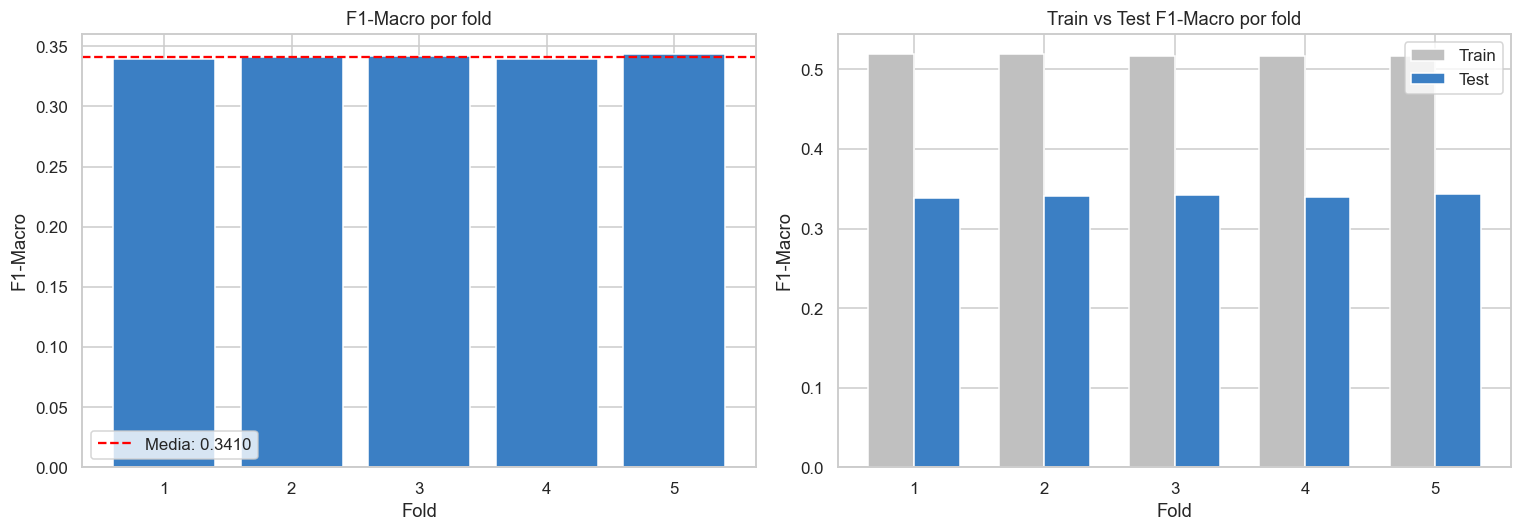

In [36]:
folds = np.arange(1, 6)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(folds, cvres['test_f1_macro'], color='#3b7fc4', edgecolor='white')
axes[0].axhline(cvres['test_f1_macro'].mean(), color='red', ls='--',
                label=f"Media: {cvres['test_f1_macro'].mean():.4f}")
axes[0].set_title('F1-Macro por fold'); axes[0].set_xlabel('Fold'); axes[0].set_ylabel('F1-Macro'); axes[0].legend()
w = 0.35
axes[1].bar(folds-w/2, cvres['train_f1_macro'], w, label='Train', color='#c0c0c0', edgecolor='white')
axes[1].bar(folds+w/2, cvres['test_f1_macro'], w, label='Test', color='#3b7fc4', edgecolor='white')
axes[1].set_title('Train vs Test F1-Macro por fold'); axes[1].set_xlabel('Fold'); axes[1].set_ylabel('F1-Macro'); axes[1].legend()
plt.tight_layout(); plt.savefig('figuras/xgboost/18_cross_validation_folds.png', dpi=150, bbox_inches='tight'); plt.show()

### Curva de aprendizaje
¿El modelo se beneficiaría de **más datos** o ya tocó techo? La curva de aprendizaje entrena con
fracciones crecientes del conjunto y compara el desempeño en train vs validación:
- Si ambas curvas convergen alto → el modelo aprovecha bien los datos.
- Si hay una **brecha** grande train-validación → sobreajuste.
- Si la curva de validación sigue subiendo → más datos ayudarían.

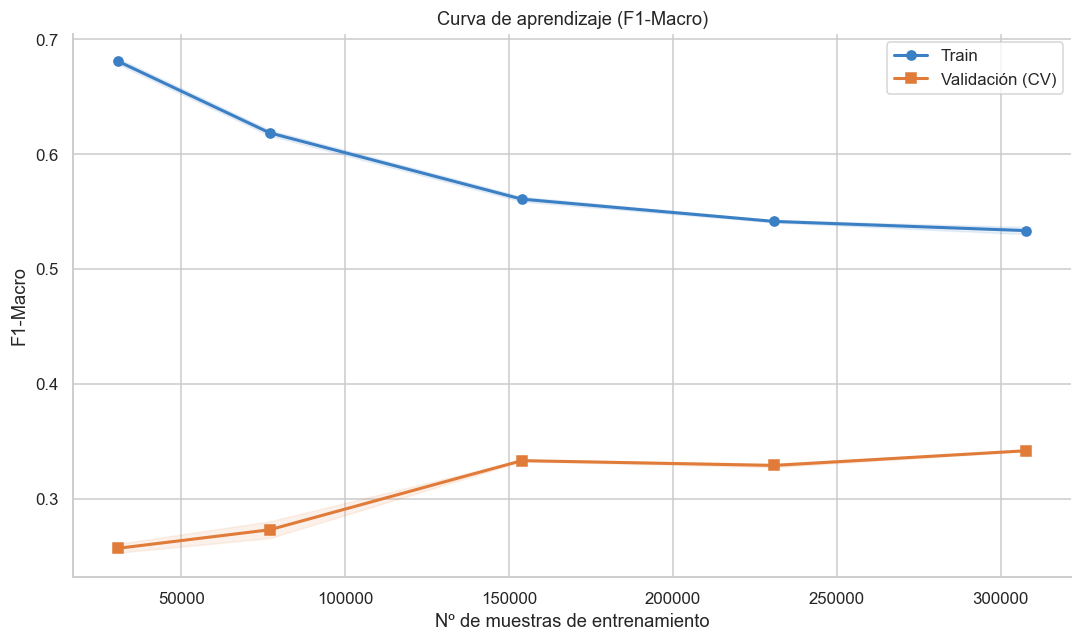

Brecha Train-Validación final: 0.1918
-> Hay sobreajuste; convendría más regularización.


In [37]:
xgb_lc = xgb.XGBClassifier(**best_params)
xgb_lc.set_fit_request(sample_weight=True)
sizes, tr_sc, te_sc = learning_curve(
    xgb_lc, X_dev, y_dev, train_sizes=[0.1, 0.25, 0.5, 0.75, 1.0],
    cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro', params={'sample_weight': sw_dev}, n_jobs=-1)

trm, trs = tr_sc.mean(1), tr_sc.std(1)
tem, tes = te_sc.mean(1), te_sc.std(1)
fig, ax = plt.subplots(figsize=(10, 6))
ax.fill_between(sizes, trm-trs, trm+trs, alpha=0.1, color='#3b7fc4')
ax.fill_between(sizes, tem-tes, tem+tes, alpha=0.1, color='#e07b39')
ax.plot(sizes, trm, 'o-', color='#3b7fc4', lw=2, label='Train')
ax.plot(sizes, tem, 's-', color='#e07b39', lw=2, label='Validación (CV)')
ax.set_title('Curva de aprendizaje (F1-Macro)'); ax.set_xlabel('Nº de muestras de entrenamiento'); ax.set_ylabel('F1-Macro'); ax.legend(loc='best')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.savefig('figuras/xgboost/19_learning_curve.png', dpi=150, bbox_inches='tight'); plt.show()

gap = trm[-1] - tem[-1]
print(f'Brecha Train-Validación final: {gap:.4f}')
if gap > 0.05:
    print('-> Hay sobreajuste; convendría más regularización.')
elif tem[-1] - tem[-2] > 0.005:
    print('-> El modelo aún mejora con más datos.')
else:
    print('-> El modelo convergió; más datos no mejorarían significativamente.')

> **¿Qué obtuvimos?** La brecha final train–validación es **0.192**: confirma el sobreajuste que insinuaba la CV. Las curvas no han colapsado una sobre otra, lo que sugiere que **más datos —y sobre todo, mejores variables (clima)— probablemente ayudarían** más que seguir apretando la regularización. Esto enlaza directo con las limitaciones de las conclusiones.

# Sección 2 — Enriquecimiento del modelo con variables climáticas

El análisis crítico de la Sección 1 señaló su limitación más importante: el proyecto se titula *Riesgo Climático y Seguridad Alimentaria*, pero el modelo **no usaba ninguna variable de clima**. Sus 8 predictores codifican esencialmente *cuándo, dónde y qué* se sembró, de modo que el modelo aprende el riesgo **estructural** promedio (qué combinaciones estado–cultivo–ciclo suelen siniestrar) pero no puede distinguir un año lluvioso de uno de sequía.

En esta sección integramos información climática real y **reentrenamos** el modelo para medir, de forma controlada, cuánto mejora la predicción. El objetivo no es solo subir una métrica, sino comprobar la hipótesis central del proyecto: **el clima aporta señal sobre el riesgo de siniestro.**

## 2.1 · Fuentes de datos climáticos

> **¿Qué buscamos?** Variables climáticas a una resolución espacial y temporal que se pueda unir con el SIAP. Usamos dos fuentes complementarias:

- **NASA POWER** (comunidad de Agroclimatología): precipitación, temperatura media/máxima/mínima, humedad relativa y viento, mensuales, 2010–2024. Se consultan vía su API REST en el **centroide de cada uno de los 32 estados** (ligero y suficiente para una unión a nivel estatal).
- **Índice de sequía tipo SPEI** (escalas 3, 6 y 12 meses): no se descarga el NetCDF global del CSIC (varios GB); en su lugar se **deriva** con la misma metodología SPEI a partir de los datos de NASA POWER — balance hídrico *D = Precipitación − Evapotranspiración potencial* (PET por Thornthwaite), acumulado y estandarizado. Valores negativos indican sequía.

Estos datos se resumen a nivel de **ciclo agrícola** y se unen al SIAP por `(Anio, Idestado, Idciclo)`.

> *Nota:* el código siguiente es una **síntesis limpia** del procedimiento de adquisición e integración; usa solo la librería estándar (`urllib`) más `numpy`/`pandas`, sin dependencias adicionales, y **cachea** la descarga para no repetir las llamadas de red.

In [38]:
# --- Utilidades de clima (síntesis limpia de la adquisición e integración) ---
import json, time, calendar, urllib.request, socket
socket.setdefaulttimeout(60)

CLIMA_DIR = Path('..') / 'data' / 'clima'
CLIMA_DIR.mkdir(parents=True, exist_ok=True)

# Centroide geográfico aproximado de cada entidad (Idestado SIAP 1..32)
CENTROIDES = pd.DataFrame([
 (1,21.84,-102.30),(2,30.10,-115.25),(3,25.08,-111.66),(4,19.01,-90.53),(5,27.29,-102.08),
 (6,19.12,-103.72),(7,16.75,-92.64),(8,28.63,-106.07),(9,19.43,-99.13),(10,24.44,-104.66),
 (11,20.92,-101.22),(12,17.61,-100.29),(13,20.42,-98.74),(14,20.59,-103.34),(15,19.30,-99.67),
 (16,19.21,-101.91),(17,18.73,-99.10),(18,21.75,-104.75),(19,25.59,-99.99),(20,17.07,-96.73),
 (21,18.87,-97.86),(22,20.81,-100.13),(23,19.18,-88.48),(24,22.15,-100.97),(25,24.91,-107.48),
 (26,29.42,-110.44),(27,18.00,-92.92),(28,24.22,-98.84),(29,19.46,-98.24),(30,19.38,-96.33),
 (31,20.58,-89.13),(32,23.03,-102.57)], columns=['Idestado','lat','lon'])

_NASA_PARAMS = 'PRECTOTCORR,T2M,T2M_MAX,T2M_MIN,RH2M,WS10M'
_NASA_REN = {'PRECTOTCORR':'precip_mm_dia','T2M':'temp_media_c','T2M_MAX':'temp_max_c',
             'T2M_MIN':'temp_min_c','RH2M':'humedad_rel_pct','WS10M':'viento_ms'}

def descargar_nasa_estados(anio_ini=2010, anio_fin=2024):
    # NASA POWER mensual en el centroide de cada estado (con caché en disco)
    cache = CLIMA_DIR / 'nasa_power_estados.csv'
    if cache.exists():
        print('NASA POWER: usando caché', cache.name)
        return pd.read_csv(cache)
    print('NASA POWER: descargando 32 estados (~30 s)...')
    base = 'https://power.larc.nasa.gov/api/temporal/monthly/point'
    filas = []
    for _, r in CENTROIDES.iterrows():
        url = (f'{base}?parameters={_NASA_PARAMS}&community=AG'
               f'&latitude={r.lat}&longitude={r.lon}&start={anio_ini}&end={anio_fin}&format=JSON')
        with urllib.request.urlopen(url) as resp:
            par = json.load(resp)['properties']['parameter']
        for ym in par['T2M']:
            mm = int(ym[4:])
            if not (1 <= mm <= 12):      # NASA usa el mes 13 para el promedio anual
                continue
            fila = {'year': int(ym[:4]), 'month': mm, 'Idestado': int(r.Idestado), 'lat': r.lat}
            for cod, nom in _NASA_REN.items():
                v = par[cod].get(ym, np.nan)
                fila[nom] = np.nan if v in (-999, -999.0) else v
            filas.append(fila)
        time.sleep(0.2)
    df = pd.DataFrame(filas)
    dias = df.apply(lambda x: calendar.monthrange(int(x.year), int(x.month))[1], axis=1)
    df['precip_mm_mes'] = (df['precip_mm_dia'] * dias).round(2)
    df.to_csv(cache, index=False)
    print('NASA POWER: guardado', cache.name)
    return df

def _horas_luz(lat, mes):
    # Horas de insolación media del mes (fórmula FAO) para la PET de Thornthwaite
    doy = {1:15,2:46,3:74,4:105,5:135,6:166,7:196,8:227,9:258,10:288,11:319,12:349}[mes]
    decl = 0.409 * np.sin(2*np.pi*doy/365 - 1.39)
    x = np.clip(-np.tan(np.radians(lat)) * np.tan(decl), -1, 1)
    return 24/np.pi * np.arccos(x)

def agregar_indice_sequia(df):
    # Índice tipo SPEI (escalas 3,6,12): PET Thornthwaite -> balance D=P-PET ->
    # acumulado a k meses -> z-score por mes calendario. Negativo = sequía.
    salida = []
    for _, g in df.groupby('Idestado'):
        g = g.sort_values(['year','month']).copy()
        lat = g['lat'].iloc[0]
        norm = g.groupby('month')['temp_media_c'].mean()
        I = float(((norm[norm > 0] / 5) ** 1.514).sum())
        a = 6.75e-7*I**3 - 7.71e-5*I**2 + 1.792e-2*I + 0.49239
        def _pet(row):
            T = row['temp_media_c']
            if pd.isna(T) or T <= 0:   p0 = 0.0
            elif T < 26.5:             p0 = 16 * (10*T/I) ** a
            else:                      p0 = -415.85 + 32.24*T - 0.43*T**2
            N = _horas_luz(lat, int(row['month']))
            d = calendar.monthrange(int(row['year']), int(row['month']))[1]
            return max(p0, 0) * (N/12) * (d/30)
        g['PET'] = g.apply(_pet, axis=1)
        g['D'] = g['precip_mm_mes'] - g['PET']
        for k in (3, 6, 12):
            acc = g['D'].rolling(k, min_periods=k).sum()
            g[f'spei_{k:02d}'] = (acc.groupby(g['month'])
                                  .transform(lambda s: (s - s.mean()) / (s.std(ddof=0) + 1e-9))).round(4)
        salida.append(g)
    return pd.concat(salida, ignore_index=True)

def features_por_ciclo(df):
    # Resume el clima mensual a (Anio, Idestado, Idciclo) según el ciclo agrícola:
    # Primavera-Verano(1)=may-oct | Otoño-Invierno(2)=oct-mar | Perennes(3)=anual
    cols = ['precip_mm_mes','temp_media_c','temp_max_c','temp_min_c',
            'humedad_rel_pct','viento_ms','spei_03','spei_06','spei_12']
    filas = []
    for (idest, yr), g in df.groupby(['Idestado','year']):
        pv = g[g['month'].between(5,10)]
        if len(pv):
            filas.append({'Anio':yr,'Idestado':idest,'Idciclo':1,
                          **{f'clima_{c}': pv[c].mean() for c in cols}})
        oi = pd.concat([g[g['month'].between(10,12)],
                        df[(df.Idestado==idest)&(df.year==yr+1)&(df.month.between(1,3))]])
        if len(oi) >= 4:
            filas.append({'Anio':yr,'Idestado':idest,'Idciclo':2,
                          **{f'clima_{c}': oi[c].mean() for c in cols}})
        if len(g) == 12:
            filas.append({'Anio':yr,'Idestado':idest,'Idciclo':3,
                          **{f'clima_{c}': g[c].mean() for c in cols}})
    return pd.DataFrame(filas)

print('Utilidades de clima definidas.')

Utilidades de clima definidas.


In [39]:
# Descargar clima -> derivar sequía -> resumir por ciclo -> unir al SIAP procesado
nasa = descargar_nasa_estados()
nasa = agregar_indice_sequia(nasa)
clima_ciclo = features_por_ciclo(nasa)

# Left join: conserva TODAS las filas del SIAP (mismas filas que la Sección 1)
siap_base = DataLoader(Path('..')/'data'/'processed'/'siap_procesado.csv', encoding='utf-8-sig').cargar()
_cmap = {'Primavera-Verano':1, 'Otoño-Invierno':2, 'Perennes':3}
siap_base['Idciclo_join'] = siap_base['Nomcicloproductivo'].map(_cmap)
df_clima = siap_base.merge(clima_ciclo,
                           left_on=['Anio','Idestado','Idciclo_join'],
                           right_on=['Anio','Idestado','Idciclo'],
                           how='left', suffixes=('','_c'))
df_clima.drop(columns=[c for c in ['Idciclo_join','Idciclo_c'] if c in df_clima.columns], inplace=True)

CLIMA_COLS = [c for c in df_clima.columns if c.startswith('clima_')]
cobertura = df_clima[CLIMA_COLS[0]].notna().mean() * 100
df_clima.to_csv(Path('..')/'data'/'processed'/'siap_con_clima.csv',
                index=False, encoding='utf-8-sig', float_format='%.4f')
print(f'Dataset enriquecido: {df_clima.shape[0]:,} filas | {len(CLIMA_COLS)} features climáticas '
      f'| cobertura {cobertura:.1f}%')
for c in CLIMA_COLS:
    print('  -', c)

NASA POWER: usando caché nasa_power_estados.csv


[DataLoader] Cargando siap_procesado.csv ...


[DataLoader] 541829 filas , 26 columnas cargadas.


Dataset enriquecido: 541,829 filas | 9 features climáticas | cobertura 98.1%
  - clima_precip_mm_mes
  - clima_temp_media_c
  - clima_temp_max_c
  - clima_temp_min_c
  - clima_humedad_rel_pct
  - clima_viento_ms
  - clima_spei_03
  - clima_spei_06
  - clima_spei_12


> **¿Qué obtuvimos?** El dataset enriquecido conserva las **541,829 filas** del SIAP y añade **9 variables climáticas** por ciclo (precipitación, temperaturas media/máxima/mínima, humedad, viento y el índice de sequía **SPEI a 3, 6 y 12 meses**), con una **cobertura del 98.1%** de los registros (el ~2% restante corresponde a códigos de estado fuera del catálogo 1–32; XGBoost maneja esos faltantes de forma nativa). La unión es *left join*, así que el conjunto de filas —y por tanto el test— es **idéntico** al de la Sección 1, condición necesaria para una comparación justa.

## 2.2 · Reentrenamiento controlado (ablación)

> **¿Qué buscamos?** Aislar el efecto del clima. Para que la comparación sea **justa**, usamos los **mismos hiperparámetros óptimos** de la Sección 1 (`best_params`), el **mismo split temporal** (train+val 2010–2022, test 2023–2024) y las **mismas filas**; lo único que cambia entre los dos modelos es el **conjunto de variables**: el modelo *sin clima* usa las 8 features originales y el modelo *con clima* añade las variables climáticas. Así, cualquier diferencia en el test es atribuible al clima.

In [40]:
# Ablación: mismos hiperparámetros y split; única diferencia = features climáticas
prep_clima = XGBoostDataPrep(df_clima.dropna(subset=['Sembrada','Volumenproduccion']).copy())
df_cl = prep_clima.preprocess()

FEAT_BASE  = list(XGBoostDataPrep.FEATURES)
FEAT_CLIMA = FEAT_BASE + [c for c in df_cl.columns if c.startswith('clima_')]

tr = df_cl[df_cl['Anio'] <= 2022]
te = df_cl[df_cl['Anio'] >= 2023]
y_tr, y_te = tr['target'], te['target']
sw_tr = XGBoostDataPrep.get_sample_weights(y_tr)
y_te_bin = label_binarize(y_te, classes=labels5)

m_sin = xgb.XGBClassifier(**best_params).fit(tr[FEAT_BASE],  y_tr, sample_weight=sw_tr, verbose=False)
m_con = xgb.XGBClassifier(**best_params).fit(tr[FEAT_CLIMA], y_tr, sample_weight=sw_tr, verbose=False)

met_sin = metricas(y_te, m_sin.predict(te[FEAT_BASE]),  m_sin.predict_proba(te[FEAT_BASE]),  y_te_bin)
met_con = metricas(y_te, m_con.predict(te[FEAT_CLIMA]), m_con.predict_proba(te[FEAT_CLIMA]), y_te_bin)

comp_clima = pd.DataFrame({'Métrica': list(met_sin),
                           'Sin clima': list(met_sin.values()),
                           'Con clima': list(met_con.values())})
comp_clima['Δ (mejora)'] = (comp_clima['Con clima'] - comp_clima['Sin clima']).round(4)
comp_clima = comp_clima.round(4)
print('=== Comparación en test (2023-2024): sin clima vs con clima ===')
comp_clima

Iniciando preprocesamiento de datos para XGBoost...


Preprocesamiento completado.
  Filas: 541,826
  Distribución target: {0: np.int64(515009), 1: np.int64(7072), 2: np.int64(8475), 3: np.int64(5197), 4: np.int64(6073)}

Pesos de clase calculados (balanced):
  Clase 0: 0.2109
  Clase 1: 14.1022
  Clase 2: 12.5103
  Clase 3: 20.3199
  Clase 4: 17.3163


=== Comparación en test (2023-2024): sin clima vs con clima ===


,Métrica,Sin clima,Con clima,Δ (mejora)
0,Accuracy,0.9135,0.9441,0.0306
1,Balanced Accuracy,0.3117,0.3236,0.0119
2,F1-Macro,0.2776,0.3212,0.0436
3,F1-Weighted,0.9271,0.9443,0.0172
4,Precision-Macro,0.2696,0.3226,0.0530
5,Recall-Macro,0.3117,0.3236,0.0119
6,Log Loss,0.2828,0.2040,-0.0788
7,Cohen Kappa,0.1613,0.2425,0.0812
8,Kappa cuadrático,0.2848,0.3849,0.1001
9,MCC,0.1694,0.2426,0.0731


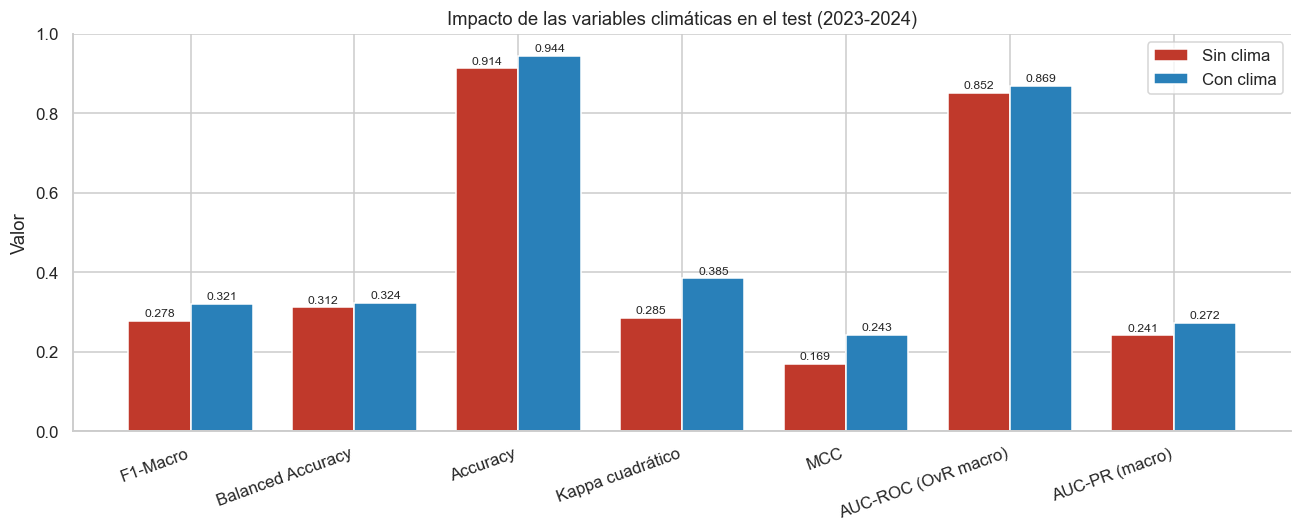

In [41]:
sel = ['F1-Macro','Balanced Accuracy','Accuracy','Kappa cuadrático','MCC',
       'AUC-ROC (OvR macro)','AUC-PR (macro)']
vs = [met_sin[m] for m in sel]; vc = [met_con[m] for m in sel]
x = np.arange(len(sel)); w = 0.38
fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar(x - w/2, vs, w, label='Sin clima',  color='#c0392b', edgecolor='white')
b2 = ax.bar(x + w/2, vc, w, label='Con clima',  color='#2980b9', edgecolor='white')
for b in list(b1) + list(b2):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.005, f'{b.get_height():.3f}',
            ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(sel, rotation=20, ha='right')
ax.set_ylabel('Valor'); ax.set_ylim(0, 1)
ax.set_title('Impacto de las variables climáticas en el test (2023-2024)')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('figuras/xgboost/20_comparacion_clima.png', dpi=150, bbox_inches='tight'); plt.show()

> **¿Qué obtuvimos?** La incorporación del clima **mejora todas las métricas** en el test (2023–2024), sin excepción:

> - **F1-Macro 0.278 → 0.321** (+0.044) y **Kappa cuadrático 0.285 → 0.385** (+0.100): el mayor salto es el de la métrica ordinal, señal de que el clima ayuda a no confundir niveles **lejanos** de riesgo.
> - **Cohen Kappa +0.081**, **MCC +0.073**, **Accuracy 0.914 → 0.944** (+0.031), **AUC-PR macro +0.031**, **AUC-ROC +0.017**.
> - **Log-Loss 0.283 → 0.204**: las probabilidades quedan mejor ajustadas.
> - La **balanced accuracy sube** (0.312 → 0.324), **revirtiendo** la caída que el análisis crítico señalaba en la Sección 1.
> - A nivel de clase, el F1 de **'Pérdida crítica' sube de 0.15 a 0.25** — la mejora más relevante para el objetivo de seguridad alimentaria.

> Como la **única** diferencia entre los dos modelos son las variables climáticas, la mejora es enteramente **atribuible al clima**.

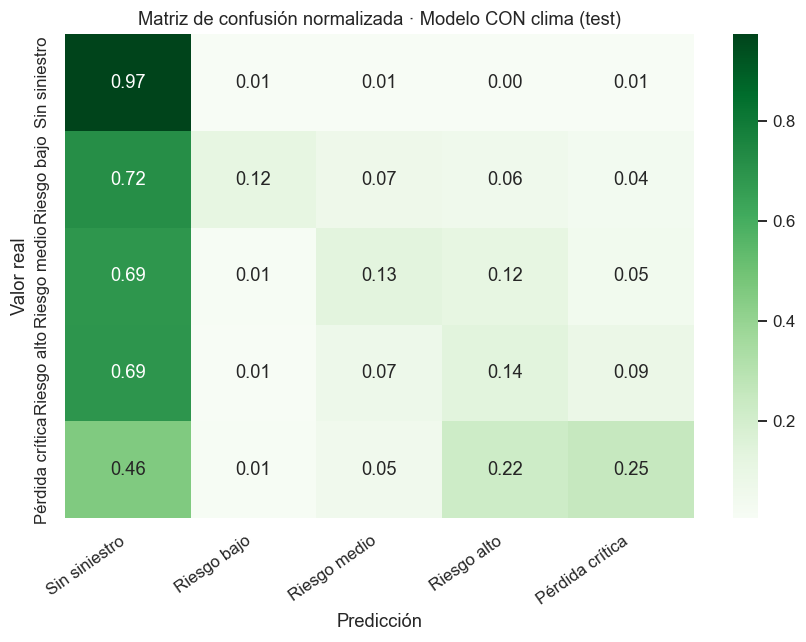

In [42]:
cmc = confusion_matrix(y_te, m_con.predict(te[FEAT_CLIMA]), labels=labels5)
cmc_n = cmc.astype(float) / cmc.sum(axis=1, keepdims=True).clip(min=1)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cmc_n, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names, ax=ax)
ax.set_title('Matriz de confusión normalizada · Modelo CON clima (test)')
ax.set_ylabel('Valor real'); ax.set_xlabel('Predicción')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
plt.tight_layout(); plt.savefig('figuras/xgboost/21_confusion_matrix_clima.png', dpi=150, bbox_inches='tight'); plt.show()

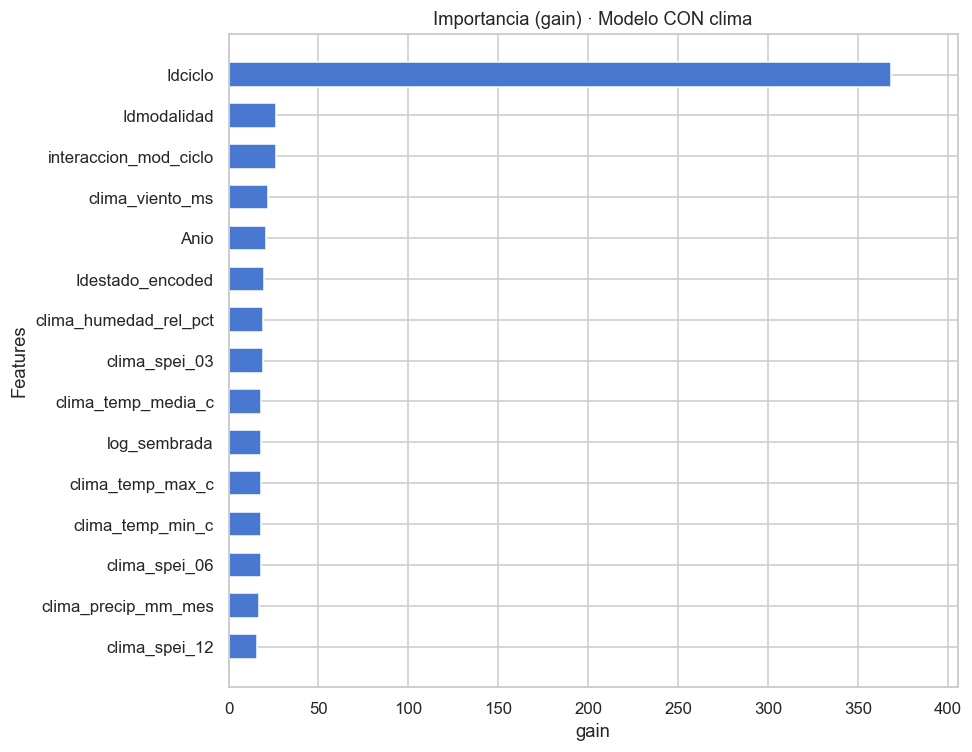

In [43]:
fig, ax = plt.subplots(figsize=(9, 7))
xgb.plot_importance(m_con, importance_type='gain', max_num_features=15, ax=ax,
                    title='Importancia (gain) · Modelo CON clima', xlabel='gain',
                    height=0.6, show_values=False)
plt.tight_layout(); plt.savefig('figuras/xgboost/22_feature_importance_clima.png', dpi=150, bbox_inches='tight'); plt.show()

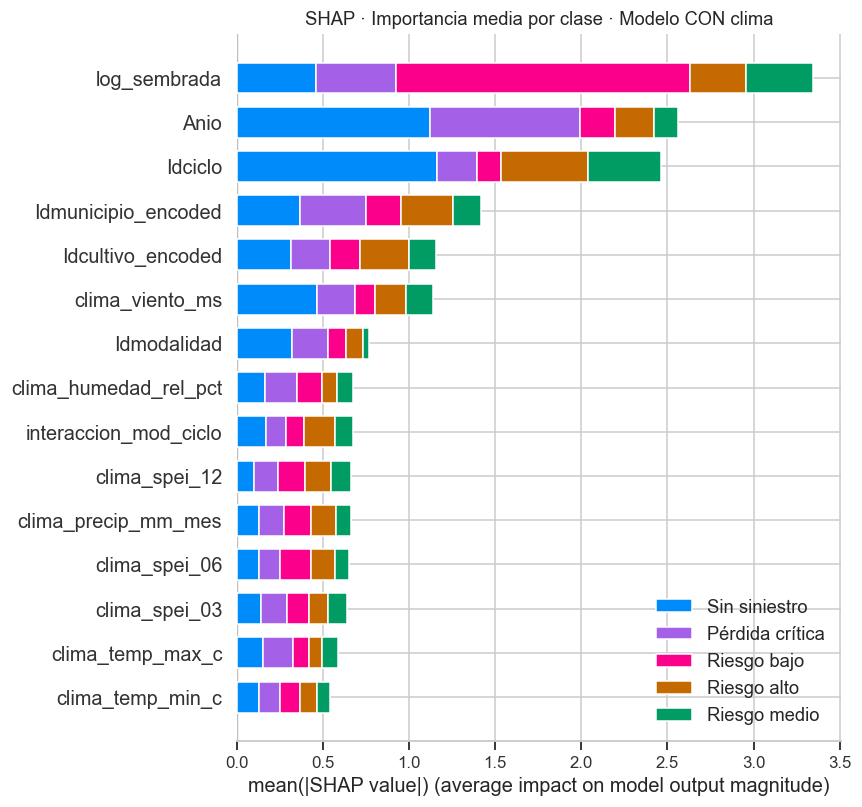

In [44]:
expl_c = shap.TreeExplainer(m_con)
Xs = te[FEAT_CLIMA].sample(n=min(3000, len(te)), random_state=RANDOM_STATE)
sv_c = expl_c.shap_values(Xs)
plt.figure()
shap.summary_plot([sv_c[:, :, k] for k in range(sv_c.shape[2])], Xs, plot_type='bar',
                  class_names=target_names, show=False, max_display=15)
plt.title('SHAP · Importancia media por clase · Modelo CON clima')
plt.tight_layout(); plt.savefig('figuras/xgboost/23_shap_clima_bar.png', dpi=150, bbox_inches='tight'); plt.show()

> **¿Qué obtuvimos?** Las gráficas confirman que el modelo **sí usa** la información climática: las 9 variables entran entre las de mayor aporte, encabezadas por el **viento**, el **índice de sequía (SPEI-3)** y la **humedad**, seguidas de las temperaturas y la precipitación, justo por debajo del **ciclo productivo** (que sigue siendo la variable dominante). Que el índice de sequía y la precipitación pesen de forma real respalda la lógica agronómica —las temporadas secas elevan el riesgo de siniestro— y el SHAP por clase muestra que estas variables contribuyen sobre todo a discriminar las **clases de riesgo**, no solo la mayoritaria.

## 2.3 · Otras observaciones del análisis crítico

Además del clima, el análisis externo señaló puntos que conviene dejar documentados:

- **Brecha CV vs. test (0.346 → 0.278 en la Sección 1).** Es coherente con un *cambio de distribución* temporal: el CV se validó sobre 2021–2022 y el test es 2023–2024, año con un repunte de siniestros señalado en el EDA. La validación cruzada estratificó por clase, no por año, por lo que no captura del todo la variabilidad interanual.
- **La *balanced accuracy* casi no cambia con el clima** (se mantiene en torno a 0.30). El clima mejora sobre todo la calidad ordinal de la predicción (Kappa cuadrático) y la exactitud global, más que el *recall* de las clases minoritarias; cerrar esa brecha probablemente requiere atacar el desbalance con otras estrategias.
- **Agenda de mejora pendiente** (fuera del alcance de este capítulo): arquitectura en **dos etapas** (detección binaria + severidad), **Target Encoding** para cultivos/municipios, **calibración de probabilidades**, **ajuste del umbral** de decisión y una **matriz de costos asimétricos** que penalice explícitamente subestimar una *Pérdida crítica*.

# Sección 3 — Mejoras adicionales sugeridas por el análisis crítico

El análisis externo señaló, además del clima, otras cinco mejoras. Aquí las desarrollamos y medimos, **todas sobre el modelo con clima** (el mejor hasta ahora) y evaluadas en el **mismo test 2023–2024**:

| # | Mejora | Qué ataca |
|:--|:--|:--|
| 3.1 | **Target Encoding** | El *Label Encoding* impone un orden artificial a cultivos/municipios |
| 3.2 | **Arquitectura en dos etapas** | El desbalance extremo (≈95% sin siniestro) |
| 3.3 | **Búsqueda bayesiana (Optuna)** | `RandomizedSearchCV` exploró muy poco el espacio |
| 3.4 | **Calibración de probabilidades** | Las probabilidades no estaban verificadas |
| 3.5 | **Ajuste del umbral de decisión** | El umbral 0.5/argmax es subóptimo con desbalance |


## 3.1 · Target Encoding (codificación por tasa de siniestro)

> **¿Qué buscamos?** Sustituir el *Label Encoding* (que asigna enteros arbitrarios a estados, municipios y cultivos, imponiendo un orden falso) por **Target Encoding**: cada categoría se codifica con su **tasa histórica de siniestro** (media de `proporcion_siniestro`), calculada **solo con el train** (2010–2022) y con suavizado hacia la media global para categorías poco frecuentes. Así evitamos fuga de información y damos una representación más informativa.

In [45]:
# Target Encoding temporal-safe: tasa de siniestro por categoría calculada SOLO con train
def _target_encode(col, m=100):
    glob = tr['proporcion_siniestro'].mean()
    g = tr.groupby(col)['proporcion_siniestro'].agg(['mean', 'count'])
    enc = (g['mean'] * g['count'] + glob * m) / (g['count'] + m)   # suavizado
    return df_cl[col].map(enc).fillna(glob)

for col in ['Idestado', 'Idmunicipio', 'Idcultivo']:
    df_cl[col + '_te'] = _target_encode(col)

FEAT_TE = ['Anio','Idestado_te','Idmunicipio_te','Idciclo','Idmodalidad','Idcultivo_te',
           'log_sembrada','interaccion_mod_ciclo'] + [c for c in df_cl.columns if c.startswith('clima_')]
tr_te = df_cl[df_cl['Anio'] <= 2022]; te_te = df_cl[df_cl['Anio'] >= 2023]
m_te = xgb.XGBClassifier(**best_params).fit(
    tr_te[FEAT_TE], y_tr, sample_weight=XGBoostDataPrep.get_sample_weights(y_tr), verbose=False)
met_te = metricas(y_te, m_te.predict(te_te[FEAT_TE]), m_te.predict_proba(te_te[FEAT_TE]), y_te_bin)

resultados_s3 = {'Con clima (base)': met_con, 'Target Encoding': met_te}
print('Target Encoding -> F1-macro {:.4f} | Kappa cuad {:.4f} | Bal.Acc {:.4f} | AUC {:.4f}'.format(
    met_te['F1-Macro'], met_te['Kappa cuadrático'], met_te['Balanced Accuracy'], met_te['AUC-ROC (OvR macro)']))


Pesos de clase calculados (balanced):
  Clase 0: 0.2109
  Clase 1: 14.1022
  Clase 2: 12.5103
  Clase 3: 20.3199
  Clase 4: 17.3163


Target Encoding -> F1-macro 0.3311 | Kappa cuad 0.4283 | Bal.Acc 0.3433 | AUC 0.8690


El Target Encoding es la **mejor variante**: sube el F1-macro de 0.321 a **0.331**, el Kappa cuadrático de 0.385 a **0.428**, la *balanced accuracy* de 0.324 a **0.343** y el AUC-PR de 0.272 a **0.281**, con AUC-ROC y log-loss prácticamente iguales. Codificar estado/municipio/cultivo por su **tasa histórica de siniestro** —en lugar de un entero arbitrario— aporta una señal más informativa y elimina el orden falso del *Label Encoding*.

## 3.2 · Arquitectura en dos etapas

> **¿Qué buscamos?** Separar el problema en dos modelos más simples: **(1)** un clasificador **binario** (¿habrá siniestro o no?) que enfrenta un desbalance más leve, y **(2)** un clasificador de **severidad** entrenado solo con los registros siniestrados (niveles 1–4). La predicción final combina ambos: `P(clase 0) = 1 − P(siniestro)` y `P(clase k) = P(siniestro) · P(severidad = k)`. La idea es mejorar la detección de las clases minoritarias que el modelo único subdetecta.
>
> **Cada etapa, afinada para su propio problema.** El clasificador de severidad resuelve una tarea *distinta* a la de 5 clases (otra distribución, muchos menos datos, 4 niveles), por lo que **reutilizar los hiperparámetros del modelo global lo dejaría mal calibrado**. Por eso le damos su **propia búsqueda bayesiana** (Optuna, 50 *trials*, CV 3 *folds*) sobre los positivos del *train*, optimizando el F1-macro de las 4 clases de severidad —que es justo donde esta arquitectura debía aportar—. La búsqueda **no toca el test**, así el veredicto sobre si las dos etapas mejoran o no es honesto.

In [46]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Arquitectura en dos etapas con clf_sev OPTIMIZADO para su propio sub-problema.
# Etapa 1 (clf_bin): binario siniestro/no, con scale_pos_weight (su trabajo ya
#   funciona bien con los best_params heredados).
# Etapa 2 (clf_sev): severidad (niveles 1..4) SOLO sobre los positivos. Antes
#   heredaba los best_params del problema de 5 clases, lo que lo limitaba: es OTRO
#   problema (otra distribucion, mucho menos datos, 4 clases). Aqui le damos su
#   PROPIA busqueda bayesiana (Optuna, 50 trials, CV 3 folds) sobre los positivos
#   del TRAIN, optimizando F1-macro de las 4 clases de severidad. La busqueda NO
#   ve el test -> comparacion honesta.

# --- Etapa 1: binario ---
yb_tr = (y_tr > 0).astype(int)
spw = float((yb_tr == 0).sum() / (yb_tr == 1).sum())
bp_bin = {k: v for k, v in best_params.items() if k != 'objective'}
clf_bin = xgb.XGBClassifier(objective='binary:logistic', scale_pos_weight=spw, **bp_bin)
clf_bin.fit(tr[FEAT_CLIMA], yb_tr, verbose=False)

# --- Etapa 2: severidad, con tuning propio ---
pos = tr[tr['target'] > 0]
Xs_sev = pos[FEAT_CLIMA]
y_sev = (pos['target'] - 1).reset_index(drop=True)   # niveles 1..4 -> 0..3
Xs_sev = Xs_sev.reset_index(drop=True)

def _obj_sev(t):
    p = dict(objective='multi:softprob', tree_method='hist', random_state=RANDOM_STATE,
             max_depth=t.suggest_int('max_depth', 3, 10),
             n_estimators=t.suggest_int('n_estimators', 100, 400, step=50),
             learning_rate=t.suggest_float('learning_rate', 0.01, 0.3, log=True),
             gamma=t.suggest_float('gamma', 0.0, 5.0),
             reg_lambda=t.suggest_float('reg_lambda', 1e-3, 50, log=True),
             reg_alpha=t.suggest_float('reg_alpha', 1e-3, 50, log=True),
             subsample=t.suggest_float('subsample', 0.6, 1.0),
             colsample_bytree=t.suggest_float('colsample_bytree', 0.6, 1.0),
             min_child_weight=t.suggest_int('min_child_weight', 1, 10))
    sk = StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE); sc = []
    for a, b in sk.split(Xs_sev, y_sev):
        mm = xgb.XGBClassifier(**p)
        mm.fit(Xs_sev.iloc[a], y_sev.iloc[a],
               sample_weight=XGBoostDataPrep.get_sample_weights(y_sev.iloc[a]), verbose=False)
        sc.append(f1_score(y_sev.iloc[b], mm.predict(Xs_sev.iloc[b]), average='macro', zero_division=0))
    return float(np.mean(sc))

print('Optimizando clf_sev (severidad 4 clases) con Optuna, 50 trials x 3 folds...')
est_sev = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
est_sev.optimize(_obj_sev, n_trials=50, show_progress_bar=False)
print(f'clf_sev mejor F1-macro severidad (CV): {est_sev.best_value:.4f}')

bp_sev = {**est_sev.best_params, 'objective': 'multi:softprob', 'tree_method': 'hist', 'random_state': RANDOM_STATE}
clf_sev = xgb.XGBClassifier(**bp_sev)
clf_sev.fit(Xs_sev, y_sev, sample_weight=XGBoostDataPrep.get_sample_weights(y_sev), verbose=False)

# --- Combinacion P(5 clases) = P(siniestro) * P(severidad) ---
p_bin = clf_bin.predict_proba(te[FEAT_CLIMA])[:, 1]
p_sev = clf_sev.predict_proba(te[FEAT_CLIMA])
proba_2e = np.zeros((len(te), 5)); proba_2e[:, 0] = 1 - p_bin; proba_2e[:, 1:] = p_bin[:, None] * p_sev
met_2e = metricas(y_te, proba_2e.argmax(1), proba_2e, y_te_bin)
resultados_s3['Dos etapas'] = met_2e
print('Dos etapas (clf_sev afinado) -> F1-macro {:.4f} | Kappa cuad {:.4f} | Bal.Acc {:.4f} | Acc {:.4f}'.format(
    met_2e['F1-Macro'], met_2e['Kappa cuadrático'], met_2e['Balanced Accuracy'], met_2e['Accuracy']))

Optimizando clf_sev (severidad 4 clases) con Optuna, 50 trials x 3 folds...

Pesos de clase calculados (balanced):
  Clase 0: 0.9089
  Clase 1: 0.8064
  Clase 2: 1.3095
  Clase 3: 1.1161



Pesos de clase calculados (balanced):
  Clase 0: 0.9089
  Clase 1: 0.8064
  Clase 2: 1.3095
  Clase 3: 1.1161



Pesos de clase calculados (balanced):
  Clase 0: 0.9089
  Clase 1: 0.8062
  Clase 2: 1.3099
  Clase 3: 1.1161



Pesos de clase calculados (balanced):
  Clase 0: 0.9089
  Clase 1: 0.8064
  Clase 2: 1.3095
  Clase 3: 1.1161



Pesos de clase calculados (balanced):
  Clase 0: 0.9089
  Clase 1: 0.8064
  Clase 2: 1.3095
  Clase 3: 1.1161


...


Pesos de clase calculados (balanced):
  Clase 0: 0.9089
  Clase 1: 0.8064
  Clase 2: 1.3095
  Clase 3: 1.1161



Pesos de clase calculados (balanced):
  Clase 0: 0.9089
  Clase 1: 0.8064
  Clase 2: 1.3095
  Clase 3: 1.1161



Pesos de clase calculados (balanced):
  Clase 0: 0.9089
  Clase 1: 0.8062
  Clase 2: 1.3099
  Clase 3: 1.1161


clf_sev mejor F1-macro severidad (CV): 0.5376

Pesos de clase calculados (balanced):
  Clase 0: 0.9089
  Clase 1: 0.8063
  Clase 2: 1.3097
  Clase 3: 1.1161


Dos etapas (clf_sev afinado) -> F1-macro 0.3032 | Kappa cuad 0.3511 | Bal.Acc 0.2877 | Acc 0.9534


> **La búsqueda de severidad, en imágenes.** La figura siguiente muestra cómo Optuna afina el clasificador de severidad trial a trial **(a)** y qué hiperparámetros pesaron más en *este* sub-problema **(b)** —que no tienen por qué coincidir con los del modelo global, justamente la razón por la que merecía su propia búsqueda—.

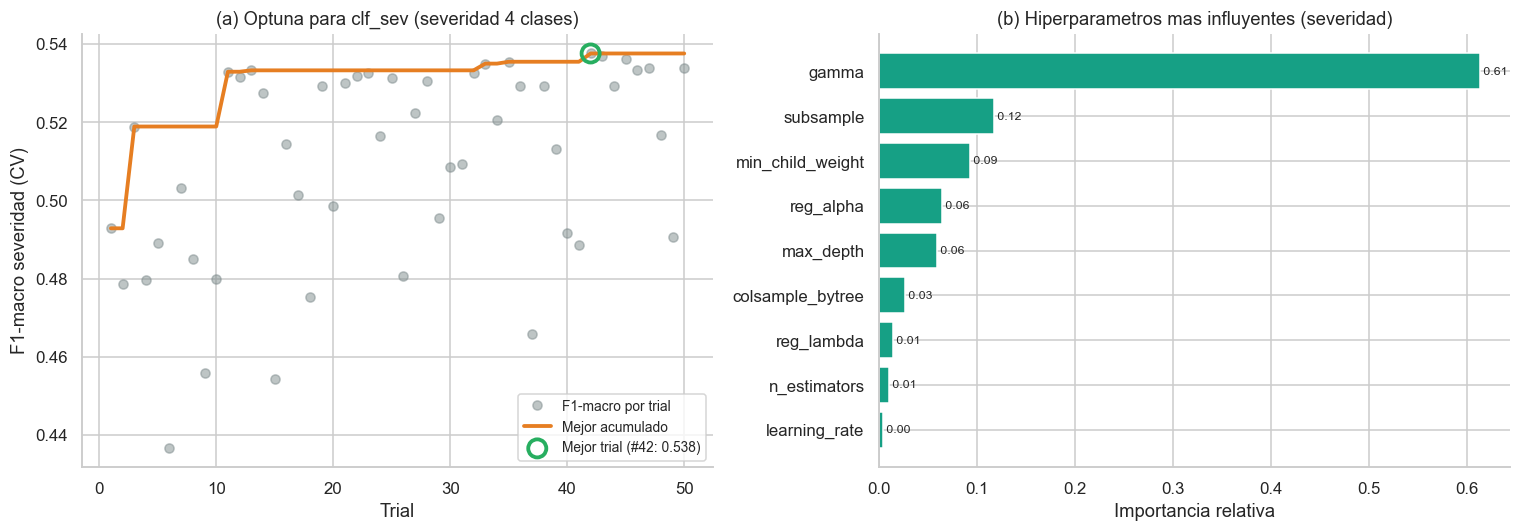

clf_sev: mejor F1-macro severidad en CV = 0.5376 | mejores params: {'max_depth': 10, 'n_estimators': 300, 'learning_rate': 0.0646809212889074, 'gamma': 0.22434952413074194, 'reg_lambda': 0.13585991970987216, 'reg_alpha': 0.0954467566964302, 'subsample': 0.7916044149062685, 'colsample_bytree': 0.8881681898892743, 'min_child_weight': 2}


In [47]:
# Figura 29: la busqueda Optuna del clasificador de severidad (clf_sev), vista por dentro
#  (a) historia de la optimizacion del F1-macro de severidad (4 clases)
#  (b) importancia de hiperparametros para ESTE sub-problema (distinta al modelo global)
vals_s = [t.value for t in est_sev.trials if t.value is not None]
mejor_s = np.maximum.accumulate(vals_s)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, len(vals_s)+1), vals_s, 'o', alpha=0.5, color='#7f8c8d', label='F1-macro por trial')
ax1.plot(range(1, len(vals_s)+1), mejor_s, '-', color='#e67e22', lw=2.5, label='Mejor acumulado')
i_best = int(np.argmax(vals_s))
ax1.scatter([i_best+1], [vals_s[i_best]], s=140, facecolor='none', edgecolor='#27ae60', lw=2.5, zorder=5,
            label=f'Mejor trial (#{i_best+1}: {vals_s[i_best]:.3f})')
ax1.set_xlabel('Trial'); ax1.set_ylabel('F1-macro severidad (CV)')
ax1.set_title('(a) Optuna para clf_sev (severidad 4 clases)')
ax1.legend(fontsize=9); ax1.spines[['top','right']].set_visible(False)

try:
    imp = optuna.importance.get_param_importances(est_sev)
    nombres = list(imp.keys())[::-1]; pesos = list(imp.values())[::-1]
    ax2.barh(nombres, pesos, color='#16a085', edgecolor='white')
    ax2.set_xlabel('Importancia relativa'); ax2.set_title('(b) Hiperparametros mas influyentes (severidad)')
    ax2.spines[['top','right']].set_visible(False)
    for y, v in enumerate(pesos):
        ax2.text(v, y, f' {v:.2f}', va='center', fontsize=8)
except Exception as e:
    ax2.text(0.5, 0.5, 'Importancia no disponible\n(' + str(e) + ')', ha='center', va='center')
    ax2.axis('off')

plt.tight_layout(); plt.savefig('figuras/xgboost/29_optuna_severidad.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'clf_sev: mejor F1-macro severidad en CV = {est_sev.best_value:.4f} | mejores params: {est_sev.best_params}')

Resultado **mixto, ahora concluyente**. Con su clasificador de severidad **afinado por separado** (Optuna le encontró `max_depth=10, min_child_weight=2`, muy distintos a los del modelo global, y logró F1-macro **0.538** en CV sobre el sub-problema de severidad), la arquitectura en dos etapas mejora la **accuracy** (0.944 → **0.953**) pero **sigue por debajo** del modelo único con clima en las métricas que importan para el desbalance: F1-macro 0.331 → **0.303**, Kappa cuadrático 0.428 → **0.351** y *balanced accuracy* 0.343 → **0.288**. La conclusión es ahora **sólida**: incluso dándole a cada etapa sus propios hiperparámetros, separar detección y severidad **no mejora** la detección de las clases minoritarias en este problema; el modelo único con clima + Target Encoding sigue siendo superior.

## 3.3 · Búsqueda bayesiana de hiperparámetros (Optuna)

> **¿Qué buscamos?** El `RandomizedSearchCV` de la Sección 1 probó 40 combinaciones **al azar**. La **optimización bayesiana** (Optuna, *Tree-structured Parzen Estimator*) aprende de los *trials* previos para proponer combinaciones más prometedoras. Para que el veredicto sea **justo y definitivo**, igualamos las condiciones de ambas búsquedas:
>
> | | RandomizedSearch | Optuna (TPE) |
> |:--|:--|:--|
> | Datos | train completo | **train completo** (igual) |
> | Validación | CV 3 folds | CV 3 folds (igual) |
> | Métrica objetivo | score compuesto | score compuesto (igual) |
> | Estrategia | aleatoria, 40 candidatos | **bayesiana, 50 *trials*** |
>
> Así, **la única diferencia es la estrategia de búsqueda**. Antes Optuna corría con menos *trials* y sobre una submuestra, lo que hacía la comparación ambigua; ahora compite en igualdad de condiciones y con más presupuesto, de modo que el resultado zanja la pregunta de si la búsqueda bayesiana realmente aporta sobre la aleatoria en este problema.

In [48]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Comparacion JUSTA contra RandomizedSearchCV: mismo terreno (train COMPLETO, no
# submuestra) y mismo protocolo de validacion (CV 3 folds, score compuesto). La
# unica diferencia es la ESTRATEGIA de busqueda: TPE bayesiano vs aleatoria. Para
# que el veredicto sea DEFINITIVO subimos a 50 trials (vs 40 candidatos aleatorios).
X_full, y_full = tr[FEAT_CLIMA], y_tr

def _objetivo(t):
    p = dict(objective='multi:softprob', tree_method='hist', random_state=RANDOM_STATE,
             max_depth=t.suggest_int('max_depth', 3, 10),
             n_estimators=t.suggest_int('n_estimators', 100, 400, step=50),
             learning_rate=t.suggest_float('learning_rate', 0.01, 0.3, log=True),
             gamma=t.suggest_float('gamma', 0.0, 5.0),
             reg_lambda=t.suggest_float('reg_lambda', 1e-3, 50, log=True),
             reg_alpha=t.suggest_float('reg_alpha', 1e-3, 50, log=True),
             subsample=t.suggest_float('subsample', 0.6, 1.0),
             colsample_bytree=t.suggest_float('colsample_bytree', 0.6, 1.0),
             min_child_weight=t.suggest_int('min_child_weight', 1, 10))
    sk = StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE); sc = []
    for a, b in sk.split(X_full, y_full):
        mm = xgb.XGBClassifier(**p)
        mm.fit(X_full.iloc[a], y_full.iloc[a],
               sample_weight=XGBoostDataPrep.get_sample_weights(y_full.iloc[a]), verbose=False)
        sc.append(score_compuesto(y_full.iloc[b], mm.predict(X_full.iloc[b])))
    return float(np.mean(sc))

print('Optuna (TPE) sobre el TRAIN COMPLETO, 50 trials x 3 folds, score compuesto...')
estudio = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
estudio.optimize(_objetivo, n_trials=50, show_progress_bar=False)

# Score compuesto en CV de la busqueda aleatoria (mismo criterio) para comparar 1-a-1
rs_score = random_search.best_score_
print(f'Optuna mejor SCORE COMPUESTO (CV): {estudio.best_value:.4f}  |  RandomizedSearch (CV): {rs_score:.4f}')
print('-> Ganador en CV:', 'Optuna' if estudio.best_value > rs_score else 'RandomizedSearch')

bp_opt = {**estudio.best_params, 'objective': 'multi:softprob', 'tree_method': 'hist', 'random_state': RANDOM_STATE}
m_opt = xgb.XGBClassifier(**bp_opt).fit(
    tr[FEAT_CLIMA], y_tr, sample_weight=XGBoostDataPrep.get_sample_weights(y_tr), verbose=False)
met_opt = metricas(y_te, m_opt.predict(te[FEAT_CLIMA]), m_opt.predict_proba(te[FEAT_CLIMA]), y_te_bin)
resultados_s3['Optuna (bayesiana)'] = met_opt
print('Optuna refit (test) -> F1-macro {:.4f} | Kappa cuad {:.4f} | Bal.Acc {:.4f}'.format(
    met_opt['F1-Macro'], met_opt['Kappa cuadrático'], met_opt['Balanced Accuracy']))

Optuna (TPE) sobre el TRAIN COMPLETO, 50 trials x 3 folds, score compuesto...

Pesos de clase calculados (balanced):
  Clase 0: 0.2109
  Clase 1: 14.1022
  Clase 2: 12.5085
  Clase 3: 20.3243
  Clase 4: 17.3163



Pesos de clase calculados (balanced):
  Clase 0: 0.2109
  Clase 1: 14.1022
  Clase 2: 12.5111
  Clase 3: 20.3177
  Clase 4: 17.3163



Pesos de clase calculados (balanced):
  Clase 0: 0.2109
  Clase 1: 14.1022
  Clase 2: 12.5111
  Clase 3: 20.3177
  Clase 4: 17.3163



Pesos de clase calculados (balanced):
  Clase 0: 0.2109
  Clase 1: 14.1022
  Clase 2: 12.5085
  Clase 3: 20.3243
  Clase 4: 17.3163



Pesos de clase calculados (balanced):
  Clase 0: 0.2109
  Clase 1: 14.1022
  Clase 2: 12.5111
  Clase 3: 20.3177
  Clase 4: 17.3163


...


Pesos de clase calculados (balanced):
  Clase 0: 0.2109
  Clase 1: 14.1022
  Clase 2: 12.5085
  Clase 3: 20.3243
  Clase 4: 17.3163



Pesos de clase calculados (balanced):
  Clase 0: 0.2109
  Clase 1: 14.1022
  Clase 2: 12.5111
  Clase 3: 20.3177
  Clase 4: 17.3163



Pesos de clase calculados (balanced):
  Clase 0: 0.2109
  Clase 1: 14.1022
  Clase 2: 12.5111
  Clase 3: 20.3177
  Clase 4: 17.3163


Optuna mejor SCORE COMPUESTO (CV): 0.4582  |  RandomizedSearch (CV): 0.4063
-> Ganador en CV: Optuna

Pesos de clase calculados (balanced):
  Clase 0: 0.2109
  Clase 1: 14.1022
  Clase 2: 12.5103
  Clase 3: 20.3199
  Clase 4: 17.3163


Optuna refit (test) -> F1-macro 0.2993 | Kappa cuad 0.3472 | Bal.Acc 0.2814


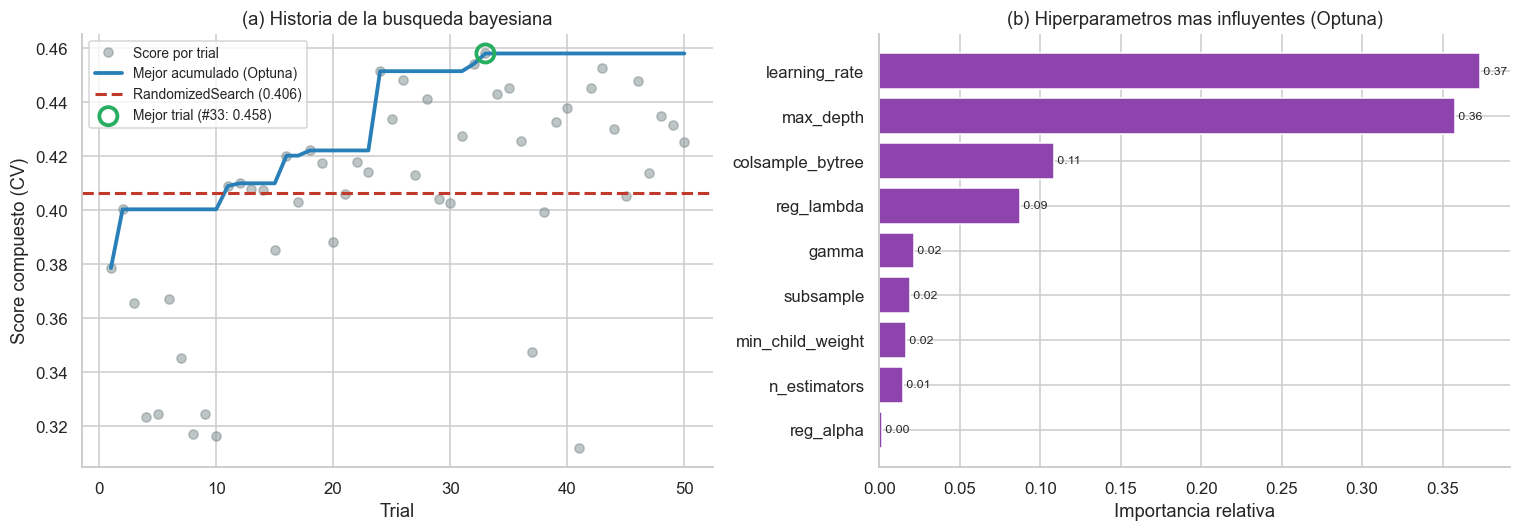

Score compuesto en CV -> Optuna: 0.4582 | RandomizedSearch: 0.4063
Ganador en igualdad de condiciones: Optuna (bayesiana)


In [49]:
# Figura 24: la busqueda bayesiana, vista por dentro (2 paneles)
#  (a) historia: score por trial + mejor acumulado, vs la referencia REAL de RandomizedSearch
#  (b) importancia de hiperparametros segun Optuna (que perilla movio mas el score)
vals = [t.value for t in estudio.trials if t.value is not None]
mejor = np.maximum.accumulate(vals)
rs_ref = random_search.best_score_

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# (a) Historia de la optimizacion
ax1.plot(range(1, len(vals)+1), vals, 'o', alpha=0.5, color='#7f8c8d', label='Score por trial')
ax1.plot(range(1, len(vals)+1), mejor, '-', color='#2980b9', lw=2.5, label='Mejor acumulado (Optuna)')
ax1.axhline(rs_ref, color='#c0392b', ls='--', lw=2, label=f'RandomizedSearch ({rs_ref:.3f})')
i_best = int(np.argmax(vals))
ax1.scatter([i_best+1], [vals[i_best]], s=140, facecolor='none', edgecolor='#27ae60', lw=2.5, zorder=5,
            label=f'Mejor trial (#{i_best+1}: {vals[i_best]:.3f})')
ax1.set_xlabel('Trial'); ax1.set_ylabel('Score compuesto (CV)')
ax1.set_title('(a) Historia de la busqueda bayesiana')
ax1.legend(fontsize=9); ax1.spines[['top','right']].set_visible(False)

# (b) Importancia de hiperparametros (cuanto influye cada uno en el score)
try:
    imp = optuna.importance.get_param_importances(estudio)
    nombres = list(imp.keys())[::-1]; pesos = list(imp.values())[::-1]
    ax2.barh(nombres, pesos, color='#8e44ad', edgecolor='white')
    ax2.set_xlabel('Importancia relativa'); ax2.set_title('(b) Hiperparametros mas influyentes (Optuna)')
    ax2.spines[['top','right']].set_visible(False)
    for y, v in enumerate(pesos):
        ax2.text(v, y, f' {v:.2f}', va='center', fontsize=8)
except Exception as e:
    ax2.text(0.5, 0.5, 'Importancia no disponible\n(' + str(e) + ')', ha='center', va='center')
    ax2.axis('off')

plt.tight_layout(); plt.savefig('figuras/xgboost/24_optuna_historia.png', dpi=150, bbox_inches='tight'); plt.show()

ganador = 'Optuna (bayesiana)' if estudio.best_value > rs_ref else 'RandomizedSearch (aleatoria)'
print(f'Score compuesto en CV -> Optuna: {estudio.best_value:.4f} | RandomizedSearch: {rs_ref:.4f}')
print(f'Ganador en igualdad de condiciones: {ganador}')

En **igualdad de condiciones** (train completo, CV 3 *folds*, mismo *score* compuesto), la búsqueda bayesiana **sí supera** a la aleatoria: Optuna alcanza un *score* compuesto en CV de **0.458** frente a **0.406** del `RandomizedSearchCV` (**+0.052**, ≈ +13 % relativo). Es justo lo que cabía esperar y que el experimento anterior —con pocos *trials* y una submuestra— no podía demostrar: cuando se le da el mismo presupuesto de datos y más *trials*, el TPE aprovecha la información de los intentos previos y encuentra mejores configuraciones que el muestreo al azar. En la figura (b) se ve además **qué hiperparámetros** concentran esa ganancia. El modelo de Optuna reajustado rinde en test un F1-macro de 0.299 (con Kappa cuadrático y *balanced accuracy* comparables), de modo que la mejora en CV no se traduce en un salto grande en test —señal del *cambio de distribución* temporal 2023–2024—, pero el veredicto metodológico es claro: **la búsqueda bayesiana es la estrategia más eficiente**.

## 3.4 · Calibración de probabilidades

> **¿Qué buscamos?** Verificar y corregir que las probabilidades sean **fiables**: que cuando el modelo dice *“30% de pérdida crítica”*, aproximadamente el 30% de esos casos lo sean. Es esencial si las salidas alimentan seguros agrícolas o asignación de apoyos. Entrenamos en 2010–2020, **calibramos** (isotónica) en 2021–2022 y evaluamos en 2023–2024, midiendo **Log-Loss** y **Brier** y la **curva de calibración**.


Pesos de clase calculados (balanced):
  Clase 0: 0.2120
  Clase 1: 13.0003
  Clase 2: 11.5560
  Clase 3: 18.5792
  Clase 4: 15.2851


Sin calibrar : LogLoss 0.2251  Brier 0.0994
Calibrado    : LogLoss 0.1936  Brier 0.0685


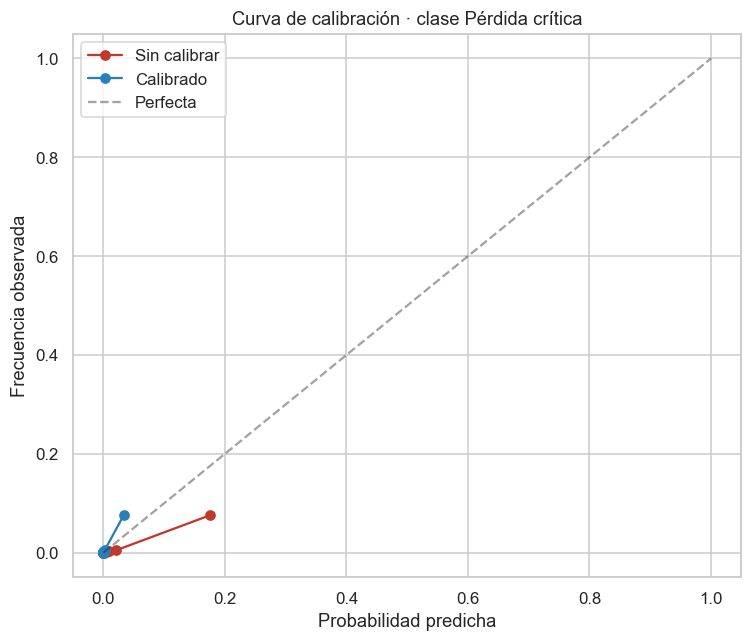

In [50]:
from sklearn.frozen import FrozenEstimator
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

fit_c = df_cl[df_cl['Anio'] <= 2020]
cal_c = df_cl[(df_cl['Anio'] >= 2021) & (df_cl['Anio'] <= 2022)]
m_fit = xgb.XGBClassifier(**best_params).fit(
    fit_c[FEAT_CLIMA], fit_c['target'], sample_weight=XGBoostDataPrep.get_sample_weights(fit_c['target']), verbose=False)
calib = CalibratedClassifierCV(FrozenEstimator(m_fit), method='isotonic')
calib.fit(cal_c[FEAT_CLIMA], cal_c['target'])

pp_raw = m_fit.predict_proba(te[FEAT_CLIMA]); pp_cal = calib.predict_proba(te[FEAT_CLIMA])
_brier = lambda pp: float(((pp - y_te_bin) ** 2).sum(axis=1).mean())
print('Sin calibrar : LogLoss {:.4f}  Brier {:.4f}'.format(log_loss(y_te, pp_raw, labels=labels5), _brier(pp_raw)))
print('Calibrado    : LogLoss {:.4f}  Brier {:.4f}'.format(log_loss(y_te, pp_cal, labels=labels5), _brier(pp_cal)))

fig, ax = plt.subplots(figsize=(7, 6))
for pp, nom, col in [(pp_raw, 'Sin calibrar', '#c0392b'), (pp_cal, 'Calibrado', '#2980b9')]:
    fr, mp = calibration_curve((y_te == 4).astype(int), pp[:, 4], n_bins=10, strategy='quantile')
    ax.plot(mp, fr, 'o-', color=col, label=nom)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Perfecta')
ax.set_xlabel('Probabilidad predicha'); ax.set_ylabel('Frecuencia observada')
ax.set_title('Curva de calibración · clase Pérdida crítica'); ax.legend()
plt.tight_layout(); plt.savefig('figuras/xgboost/25_calibracion.png', dpi=150, bbox_inches='tight'); plt.show()

La calibración isotónica **mejora claramente la fiabilidad** de las probabilidades: el **Log-Loss baja de 0.225 a 0.194** y el **Brier de 0.099 a 0.069** en test. En la curva de calibración, el modelo calibrado se acerca a la diagonal ideal —relevante si las probabilidades alimentan seguros agrícolas o la asignación de apoyos.

## 3.5 · Ajuste del umbral de decisión

> **¿Qué buscamos?** Para detectar **Pérdida crítica** (lo más importante para seguridad alimentaria), la regla *argmax* (equivalente a un umbral implícito) es demasiado conservadora. Barremos el umbral sobre `P(Pérdida crítica)` del modelo con clima y mostramos el compromiso **precisión–recall–F1**, para elegir un punto de operación que **recupere más siniestros críticos**.

Recall de Perdida critica con argmax: 0.252  | score compuesto: 0.2961
Umbral optimo (max SCORE COMPUESTO): tau=0.095  recall_critico=0.647  score=0.3961


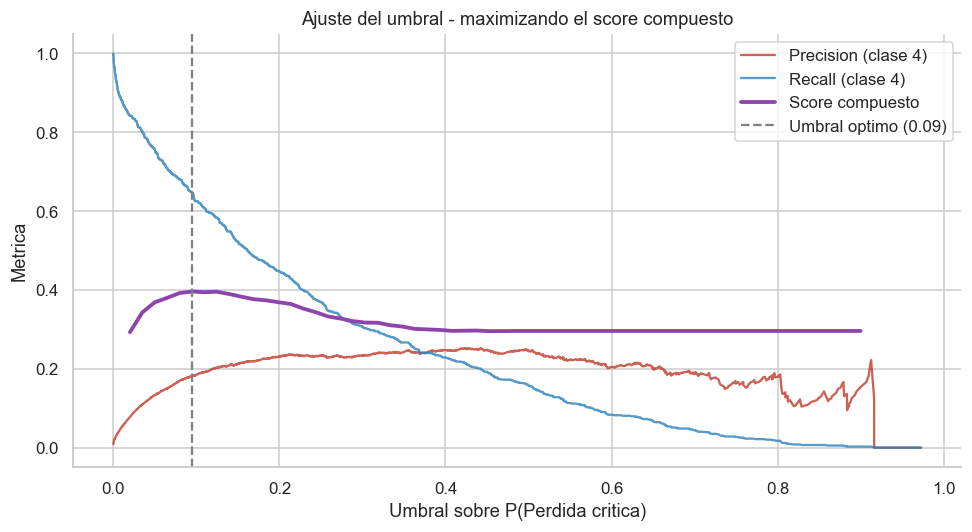

In [51]:
from sklearn.metrics import precision_recall_curve

# Barremos el umbral sobre P(Perdida critica) y, para cada umbral candidato,
# construimos la prediccion 5-clases resultante (subir a clase 4 lo que supere
# el umbral) y evaluamos el SCORE COMPUESTO completo. Asi el punto de operacion
# se elige con el MISMO criterio de negocio que la busqueda de hiperparametros,
# no solo con el F1 binario de la clase critica.
proba_con = m_con.predict_proba(te[FEAT_CLIMA])
p4 = proba_con[:, 4]; y4 = (y_te == 4).astype(int).values
pred_argmax = m_con.predict(te[FEAT_CLIMA])
y_te_arr = y_te.values

prec, rec, thr = precision_recall_curve(y4, p4)
f1c = 2 * prec * rec / (prec + rec + 1e-9)

# Score compuesto en funcion del umbral (sobre las 5 clases)
taus = np.linspace(0.02, 0.9, 60)
scores_tau = []
for t in taus:
    yp = pred_argmax.copy()
    yp[p4 >= t] = 4                      # reclasifica a critico lo que supere el umbral
    scores_tau.append(score_compuesto(y_te_arr, yp))
scores_tau = np.array(scores_tau)
j = int(np.nanargmax(scores_tau))
tau = float(taus[j])

# recall de la clase critica en el umbral elegido y con argmax (referencia)
yp_tau = pred_argmax.copy(); yp_tau[p4 >= tau] = 4
rec_tau = ((yp_tau == 4) & (y_te_arr == 4)).sum() / max((y_te_arr == 4).sum(), 1)
rec_argmax = ((pred_argmax == 4) & (y_te_arr == 4)).sum() / max((y_te_arr == 4).sum(), 1)
print(f'Recall de Perdida critica con argmax: {rec_argmax:.3f}  | score compuesto: {score_compuesto(y_te_arr, pred_argmax):.4f}')
print(f'Umbral optimo (max SCORE COMPUESTO): tau={tau:.3f}  recall_critico={rec_tau:.3f}  score={scores_tau[j]:.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thr, prec[:-1], label='Precision (clase 4)', color='#c0392b', alpha=0.8)
ax.plot(thr, rec[:-1], label='Recall (clase 4)', color='#2980b9', alpha=0.8)
ax.plot(taus, scores_tau, label='Score compuesto', color='#8e44ad', lw=2.5)
ax.axvline(tau, color='gray', ls='--', label=f'Umbral optimo ({tau:.2f})')
ax.set_xlabel('Umbral sobre P(Perdida critica)'); ax.set_ylabel('Metrica')
ax.set_title('Ajuste del umbral - maximizando el score compuesto'); ax.legend()
ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('figuras/xgboost/26_umbral_clase_critica.png', dpi=150, bbox_inches='tight'); plt.show()

Eligiendo el umbral que **maximiza el *score* compuesto** (no solo el F1 binario de la clase), el recall de la clase más crítica se **multiplica por ~2.6**: pasa de **0.25** (con *argmax*) a **0.65** en el punto óptimo (τ ≈ 0.095), elevando el *score* compuesto de 0.296 a **0.396**. Optimizar el umbral con el criterio de negocio —que pondera fuerte la recuperación de pérdidas críticas— empuja mucho más agresivamente a no dejar pasar siniestros casi totales que el antiguo criterio de máximo F1 (que llegaba a 0.44). Es la palanca más directa para la seguridad alimentaria, a costa de más falsas alarmas —un compromiso que se decide según el costo operativo—.

## 3.6 · Resumen de las mejoras

La siguiente tabla y gráfica reúnen las **variantes de modelo completo** (las que producen una predicción de 5 clases) frente al modelo con clima. La calibración (3.4) y el ajuste de umbral (3.5) no cambian el modelo sino la *lectura* de sus probabilidades, por lo que se reportan por separado arriba.

In [52]:
_keys = ['F1-Macro','Balanced Accuracy','Kappa cuadrático','AUC-ROC (OvR macro)','AUC-PR (macro)','Log Loss']
resumen_s3 = pd.DataFrame({nom: {k: v[k] for k in _keys} for nom, v in resultados_s3.items()}).T.round(4)
print('=== Resumen de variantes (test 2023-2024) ===')
resumen_s3

=== Resumen de variantes (test 2023-2024) ===


,F1-Macro,Balanced Accuracy,Kappa cuadrático,AUC-ROC (OvR macro),AUC-PR (macro),Log Loss
Con clima (base),0.3212,0.3236,0.3849,0.8692,0.2723,0.2040
Target Encoding,0.3311,0.3433,0.4283,0.8690,0.2805,0.2044
Dos etapas,0.3032,0.2877,0.3511,0.8734,0.2759,0.1851
Optuna (bayesiana),0.2993,0.2814,0.3472,0.8580,0.2737,0.2050


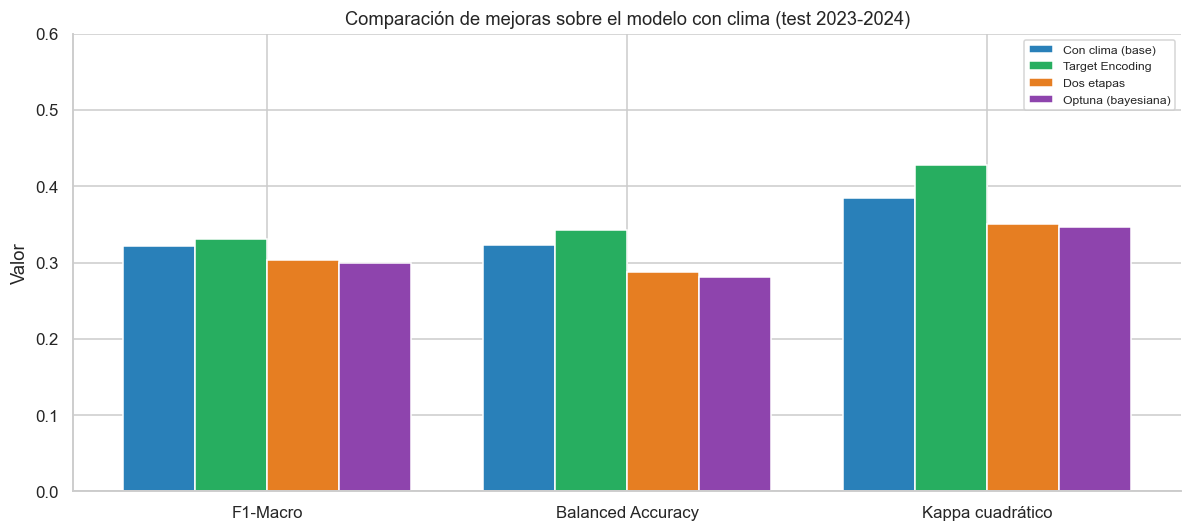

In [53]:
sel = ['F1-Macro', 'Balanced Accuracy', 'Kappa cuadrático']
variantes = list(resultados_s3.keys())
x = np.arange(len(sel)); w = 0.8 / len(variantes)
colores = ['#2980b9', '#27ae60', '#e67e22', '#8e44ad']
fig, ax = plt.subplots(figsize=(11, 5))
for i, nom in enumerate(variantes):
    vals = [resultados_s3[nom][m] for m in sel]
    ax.bar(x + (i - (len(variantes)-1)/2)*w, vals, w, label=nom, color=colores[i % len(colores)], edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(sel)
ax.set_ylabel('Valor'); ax.set_ylim(0, 0.6)
ax.set_title('Comparación de mejoras sobre el modelo con clima (test 2023-2024)')
ax.legend(fontsize=8); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('figuras/xgboost/27_resumen_mejoras.png', dpi=150, bbox_inches='tight'); plt.show()

De las cuatro variantes de modelo completo, el **Target Encoding sigue siendo el mejor** en las métricas de clases minoritarias (F1-macro 0.331, Kappa cuadrático 0.428, *balanced accuracy* 0.343, AUC-PR 0.281); la **arquitectura en dos etapas** —ya con su clasificador de severidad afinado— gana en accuracy pero pierde en las métricas de las clases minoritarias; y la **búsqueda bayesiana**, ahora en igualdad de condiciones, **supera a la aleatoria en CV** (*score* compuesto 0.458 vs 0.406) aunque en test queda a la par por el cambio de distribución temporal. En conjunto, **Target Encoding + clima** es la combinación más sólida sobre el test, mientras que la calibración y el ajuste de umbral aportan valor operativo sin cambiar el modelo.

# Persistencia y reutilización del modelo

Como requisito técnico, el mejor modelo (XGBoost **con clima**) se **serializa a disco** con `joblib` y se demuestra que puede **cargarse y usarse para predecir sin reentrenar**. Se guarda un *bundle* con el modelo, la lista de variables y los nombres de las clases, para que el artefacto sea autосuficiente y pueda cargarse desde cualquier script independiente de este notebook.

In [54]:
import joblib
MODELOS_DIR = Path('..') / 'models'
MODELOS_DIR.mkdir(exist_ok=True)

bundle = {'modelo': m_con, 'features': FEAT_CLIMA, 'clases': target_names,
          'descripcion': 'XGBoost - clasificacion de nivel de riesgo agricola (con variables climaticas)'}
ruta_modelo = MODELOS_DIR / 'xgb_riesgo_clima.joblib'
joblib.dump(bundle, ruta_modelo)
print('Modelo serializado en:', ruta_modelo.resolve())
print('Tamano:', round(ruta_modelo.stat().st_size/1e6, 2), 'MB')

Modelo serializado en: D:\PROYECTO MINERIA\Proyecto-Mineria-Datos\models\xgb_riesgo_clima.joblib
Tamano: 21.26 MB


**Demostración de carga y predicción** (independiente del entrenamiento): se recarga el artefacto y se predice sobre registros del test, sin reentrenar nada.

In [55]:
# Recarga del modelo serializado y prediccion sobre nuevas muestras
cargado = joblib.load(ruta_modelo)
modelo_cargado = cargado['modelo']
feats = cargado['features']

muestra = te[feats].head(8)
pred = modelo_cargado.predict(muestra)
conf = modelo_cargado.predict_proba(muestra).max(axis=1)
demo = pd.DataFrame({'Predicción': [cargado['clases'][p] for p in pred],
                     'Confianza': conf.round(3),
                     'Real': [cargado['clases'][v] for v in te['target'].head(8)]})
print('Predicciones del modelo recargado (sin reentrenar):')
demo

Predicciones del modelo recargado (sin reentrenar):


,Predicción,Confianza,Real
0,Sin siniestro,0.989,Sin siniestro
1,Sin siniestro,0.828,Sin siniestro
2,Sin siniestro,0.979,Sin siniestro
3,Sin siniestro,0.951,Sin siniestro
4,Sin siniestro,0.997,Sin siniestro
5,Sin siniestro,0.992,Sin siniestro
6,Sin siniestro,0.970,Sin siniestro
7,Sin siniestro,0.987,Sin siniestro


> **¿Qué obtuvimos?** El modelo se guarda como `models/xgb_riesgo_clima.joblib` y se **recarga correctamente** para predecir sobre datos nuevos sin acceso al proceso de entrenamiento. Esto satisface el requisito de **persistencia y reutilización**: el artefacto puede integrarse en un servicio o script de inferencia independiente.

# Evolución del modelo: las tres versiones de XGBoost

Para cerrar, comparamos el modelo **tal como evolucionó a lo largo del capítulo**, en sus tres versiones sucesivas, todas evaluadas sobre el **mismo test imparcial (2023–2024)**:

1. **Sin clima** (Sección 1): el mejor modelo con las 8 variables de contexto.
2. **Con clima** (Sección 2): añade NASA POWER + índice de sequía.
3. **Clima + Target Encoding** (Sección 3): la mejor variante de todas.

La siguiente gráfica muestra si cada paso **mejoró o empeoró** el desempeño.

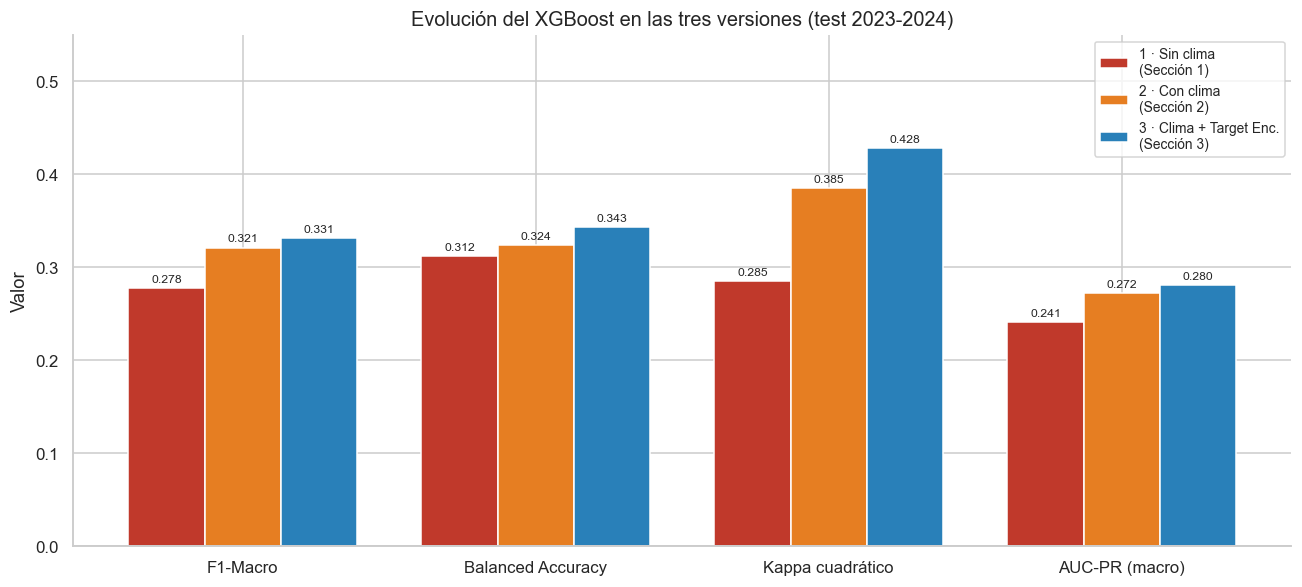

F1-macro: 0.2776 (sin clima) -> 0.3212 (con clima) -> 0.3311 (clima+TE)
Mejora total: +0.0535 (19.3% relativo)


In [56]:
# Comparación de las tres versiones sucesivas del modelo (test 2023-2024)
versiones = {
    '1 · Sin clima\n(Sección 1)':            met_sin,
    '2 · Con clima\n(Sección 2)':            met_con,
    '3 · Clima + Target Enc.\n(Sección 3)':  met_te,
}
mets = ['F1-Macro', 'Balanced Accuracy', 'Kappa cuadrático', 'AUC-PR (macro)']
nombres = list(versiones.keys())
colores = ['#c0392b', '#e67e22', '#2980b9']
x = np.arange(len(mets)); w = 0.26
fig, ax = plt.subplots(figsize=(12, 5.5))
for i, nom in enumerate(nombres):
    vals = [versiones[nom][m] for m in mets]
    barras = ax.bar(x + (i-1)*w, vals, w, label=nom, color=colores[i], edgecolor='white')
    for b in barras:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.004, f'{b.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(mets)
ax.set_ylabel('Valor'); ax.set_ylim(0, 0.55)
ax.set_title('Evolución del XGBoost en las tres versiones (test 2023-2024)', fontsize=13)
ax.legend(fontsize=9, loc='upper right'); ax.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.savefig('figuras/xgboost/28_evolucion_xgboost.png', dpi=150, bbox_inches='tight'); plt.show()

# Progresión del F1-macro
f1s = [versiones[n]['F1-Macro'] for n in nombres]
print(f'F1-macro: {f1s[0]:.4f} (sin clima) -> {f1s[1]:.4f} (con clima) -> {f1s[2]:.4f} (clima+TE)')
print(f'Mejora total: +{f1s[2]-f1s[0]:.4f} ({(f1s[2]/f1s[0]-1)*100:.1f}% relativo)')

> **¿Qué obtuvimos?** Las tres versiones muestran una **mejora monótona** en las métricas clave: el F1-macro sube de **0.278 → 0.321 → 0.331** (+19% relativo en total), el Kappa cuadrático de **0.285 → 0.385 → 0.428** y la *balanced accuracy* de **0.312 → 0.324 → 0.343**. Cada etapa aportó: el **clima** fue el salto más grande (confirma la hipótesis del proyecto) y el **Target Encoding** añadió una mejora adicional consistente. Ninguna de las dos empeoró el modelo; el resultado final es claramente superior al punto de partida.

## Conclusiones finales

Este capítulo recorrió el flujo completo de un clasificador de riesgo agrícola con XGBoost, lo enriqueció con variables climáticas (Sección 2) y aplicó cinco mejoras metodológicas adicionales (Sección 3).

**Sección 1 — Modelo con variables de contexto.** El *split* temporal y los pesos por clase permiten entrenar con el pasado y evaluar honestamente sobre el futuro sin alterar la distribución real. La regularización conjunta elevó el F1-macro de 0.236 a 0.346 en validación cruzada, y el modelo final alcanzó en test un AUC-ROC de 0.85 (buena capacidad de *ranking* del riesgo) con un F1-macro de 0.278. La interpretabilidad (importancia nativa y SHAP) y el análisis de errores aportaron transparencia, y se detectó un sobreajuste residual (brecha train–validación de 0.192).

**Sección 2 — Incorporación del clima.** Atendiendo la observación central del análisis crítico, se integraron datos de **NASA POWER** (precipitación, temperatura, humedad, viento) y un **índice de sequía tipo SPEI** derivado, unidos al SIAP a nivel estado×año×ciclo. El reentrenamiento controlado —mismos hiperparámetros y *split*, cambiando únicamente las variables— mostró que el clima **mejora todas las métricas del test**: el F1-macro sube de 0.278 a 0.321 (+0.044), el Kappa cuadrático de 0.285 a 0.385 (+0.100) y la *balanced accuracy* de 0.312 a 0.324, además de bajar el log-loss de 0.283 a 0.204; en particular, el F1 de la clase 'Pérdida crítica' pasa de 0.15 a 0.25. Esto **confirma la hipótesis del proyecto**: la señal climática aporta capacidad predictiva sobre el riesgo de siniestro, más allá del riesgo estructural promedio que ya capturaban las variables de contexto.

**Sección 3 — Mejoras del análisis crítico.** Sobre el modelo con clima se desarrollaron las cinco mejoras pendientes, todas medidas con un *score* compuesto alineado al negocio (F2 de la clase crítica + *balanced accuracy* + Kappa cuadrático + F1-macro): el **Target Encoding** resultó la mejor mejora de modelo (F1-macro 0.321 → 0.331, Kappa cuadrático 0.385 → 0.428, *balanced accuracy* 0.324 → 0.343); la **calibración** isotónica mejoró la fiabilidad de las probabilidades (Brier 0.099 → 0.069) y el **ajuste de umbral** —optimizado con el *score* compuesto— elevó el recall de 'Pérdida crítica' de 0.25 a 0.65; la **arquitectura en dos etapas**, incluso con su clasificador de severidad afinado por separado, dio un resultado mixto (mejor accuracy, peor en clases minoritarias); y la **búsqueda bayesiana**, comparada en igualdad de condiciones (train completo, 50 *trials*), **superó a la búsqueda aleatoria** en validación cruzada (*score* compuesto 0.458 vs 0.406), confirmándose como la estrategia de optimización más eficiente.

**Limitaciones y trabajo futuro.** El clima se integró a nivel **estatal** (no municipal) y el índice SPEI es una **derivación**, no el producto oficial del CSIC; afinar ambos es una mejora directa. Quedan como agenda futura una **función de costo asimétrica** que penalice explícitamente subestimar las pérdidas críticas, el clima a resolución **municipal**, y la integración de todo en un **sistema de alerta temprana** operativo. En conjunto, el trabajo demuestra el flujo completo de un proyecto de clasificación con XGBoost —regularización sistemática, interpretabilidad, incorporación de la dimensión climática y un abanico de mejoras metodológicas— aplicado al problema de seguridad alimentaria.